# Lecture 20 - Exercise - SNR classifier for LIGO data

In [3]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

#-------------------------------------------------------------------------
# maths 

import numpy                        as np
import pandas                       as pd
from   numpy.random                 import default_rng
from   scipy                        import stats, integrate, special
from   astroML                      import stats as astroMLstats

#-------------------------------------------------------------------------
# plotting 

import matplotlib                   as mpl
import matplotlib.pyplot            as plt
import corner
from   astropy.visualization.hist   import hist  as fancyhist
from   mycolorpy                    import colorlist as mcp
from   matplotlib                   import rc
from   matplotlib                   import cbook

#-------------------------------------------------------------------------
# parameter estimation with posterior sampling (MCMC, nested...)

import emcee
import dynesty
from   dynesty                      import utils as dyfunc
from   dynesty                      import plotting as dyplot

#-------------------------------------------------------------------------
# linear regression

from   astroML.linear_model         import PolynomialRegression, BasisFunctionRegression, NadarayaWatson

#-------------------------------------------------------------------------
# sklearn density estimation and dimensionality reduction

from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap, TSNE
from   sklearn.model_selection      import train_test_split, learning_curve, GridSearchCV, cross_val_predict
from   sklearn.gaussian_process     import GaussianProcessRegressor, kernels
from   sklearn.mixture              import GaussianMixture
from   sklearn.decomposition        import PCA, NMF, FastICA

#-------------------------------------------------------------------------
# classifiers 

from   sklearn.metrics               import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score
from   sklearn.cluster               import KMeans
from   sklearn.neighbors             import KNeighborsClassifier
from   sklearn.naive_bayes           import GaussianNB
from   sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from   sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from   astroML.classification        import GMMBayes
from   sklearn.ensemble              import RandomForestClassifier
from   sklearn.tree                  import DecisionTreeClassifier
from   astroML.utils                 import split_samples, completeness_contamination

#-------------------------------------------------------------------------
# standard utility

import h5py
import os
from   sys                          import stdout
from   astroML.utils.decorators     import pickle_results

#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

d:\Documents\University\Magistrale\Statistics\GitHub\working


In [4]:
#-------------------------------------------------------------------------
# Load data
#-------------------------------------------------------------------------

with h5py.File('..\..\sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r') as file_data:
    keys = file_data.keys()
    print(keys)

    x = []
    x.append(file_data['z'])
    x.append(file_data['mtot'])
    x.append(file_data['q'])
    x = np.array(x).T

    y = []
    # y.append(file_data['snr'])
    y.append(file_data['det'])
    # y = np.array(y).T
    y = np.ravel(np.array(y).T)

print(x.shape)
print(y.shape)

index_det_y = y==1
index_det_n = y==0

# index_det_y = y[:,0]==1
# index_det_n = y[:,0]==0
print(index_det_y)
print(x[index_det_y])

for i in range(3):
    print(x[:,i].min(), x[:,i].max())

#-------------------------------------------------------------------------

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>


<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
C:\Users\andre\AppData\Local\Temp\ipykernel_2996\3517190294.py:5: SyntaxWarning: invalid escape sequence '\.'
  with h5py.File('..\..\sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r') as file_data:


(20000000, 3)
(20000000,)
[False False False ... False False False]
[[7.72608580e-01 5.73821705e+02 8.46310367e-01]
 [3.78271243e-01 2.94351797e+02 6.44932896e-01]
 [1.75546701e-01 5.27367837e+02 5.99946997e-01]
 ...
 [1.63746754e-01 1.56171709e+02 7.70583246e-01]
 [1.47596317e-01 1.27545259e+02 6.02929753e-01]
 [3.00207997e-01 9.05601852e+02 8.06404980e-01]]
0.00010013117018608638 3.9999997573081307
2.000008029845597 999.9999979608655
0.10000000442777725 0.9999999697103548


In [5]:
#-------------------------------------------------------------------------
# slicing dataset for debugging
#-------------------------------------------------------------------------

N_debug = int(1e5)

x_debug = np.copy(x[:N_debug])
print(x_debug.shape)

y_debug = np.copy(y[:N_debug])
print(y_debug.shape)

#-------------------------------------------------------------------------

(100000, 3)
(100000,)


In [6]:
cmap        = mpl.cm.magma
# cmap_list   = [cmap(i) for i in range(cmap.N)]
# cmap        = mpl.colors.LinearSegmentedColormap.from_list('Custom cmap', cmap_list, cmap.N)
# cmap_bounds = [0.0,0.1,0.3,0.7,0.9,1.0]  # np.linspace(-0.5, 9.5, 11)
cmap_ticks  = [0.05,0.25,0.5,0.75,0.95] # np.linspace(0., 9., 10)
cmap_norm   = mpl.colors.Normalize(vmin=0, vmax=0.95)
contours    = np.array([0.05,0.25,0.5,0.75,0.95])

# First look at the data in the $\big( z - m_{\rm tot} - q \big)$ param space

<>:25: SyntaxWarning: invalid escape sequence '\%'
<>:25: SyntaxWarning: invalid escape sequence '\%'
C:\Users\andre\AppData\Local\Temp\ipykernel_2996\3291074085.py:25: SyntaxWarning: invalid escape sequence '\%'
  ax[0,n_dim-1].plot([], [], marker='', color='lightcoral', label='Quantiles: 5\%, 16\%, 50\%, 84\%, 95\%')


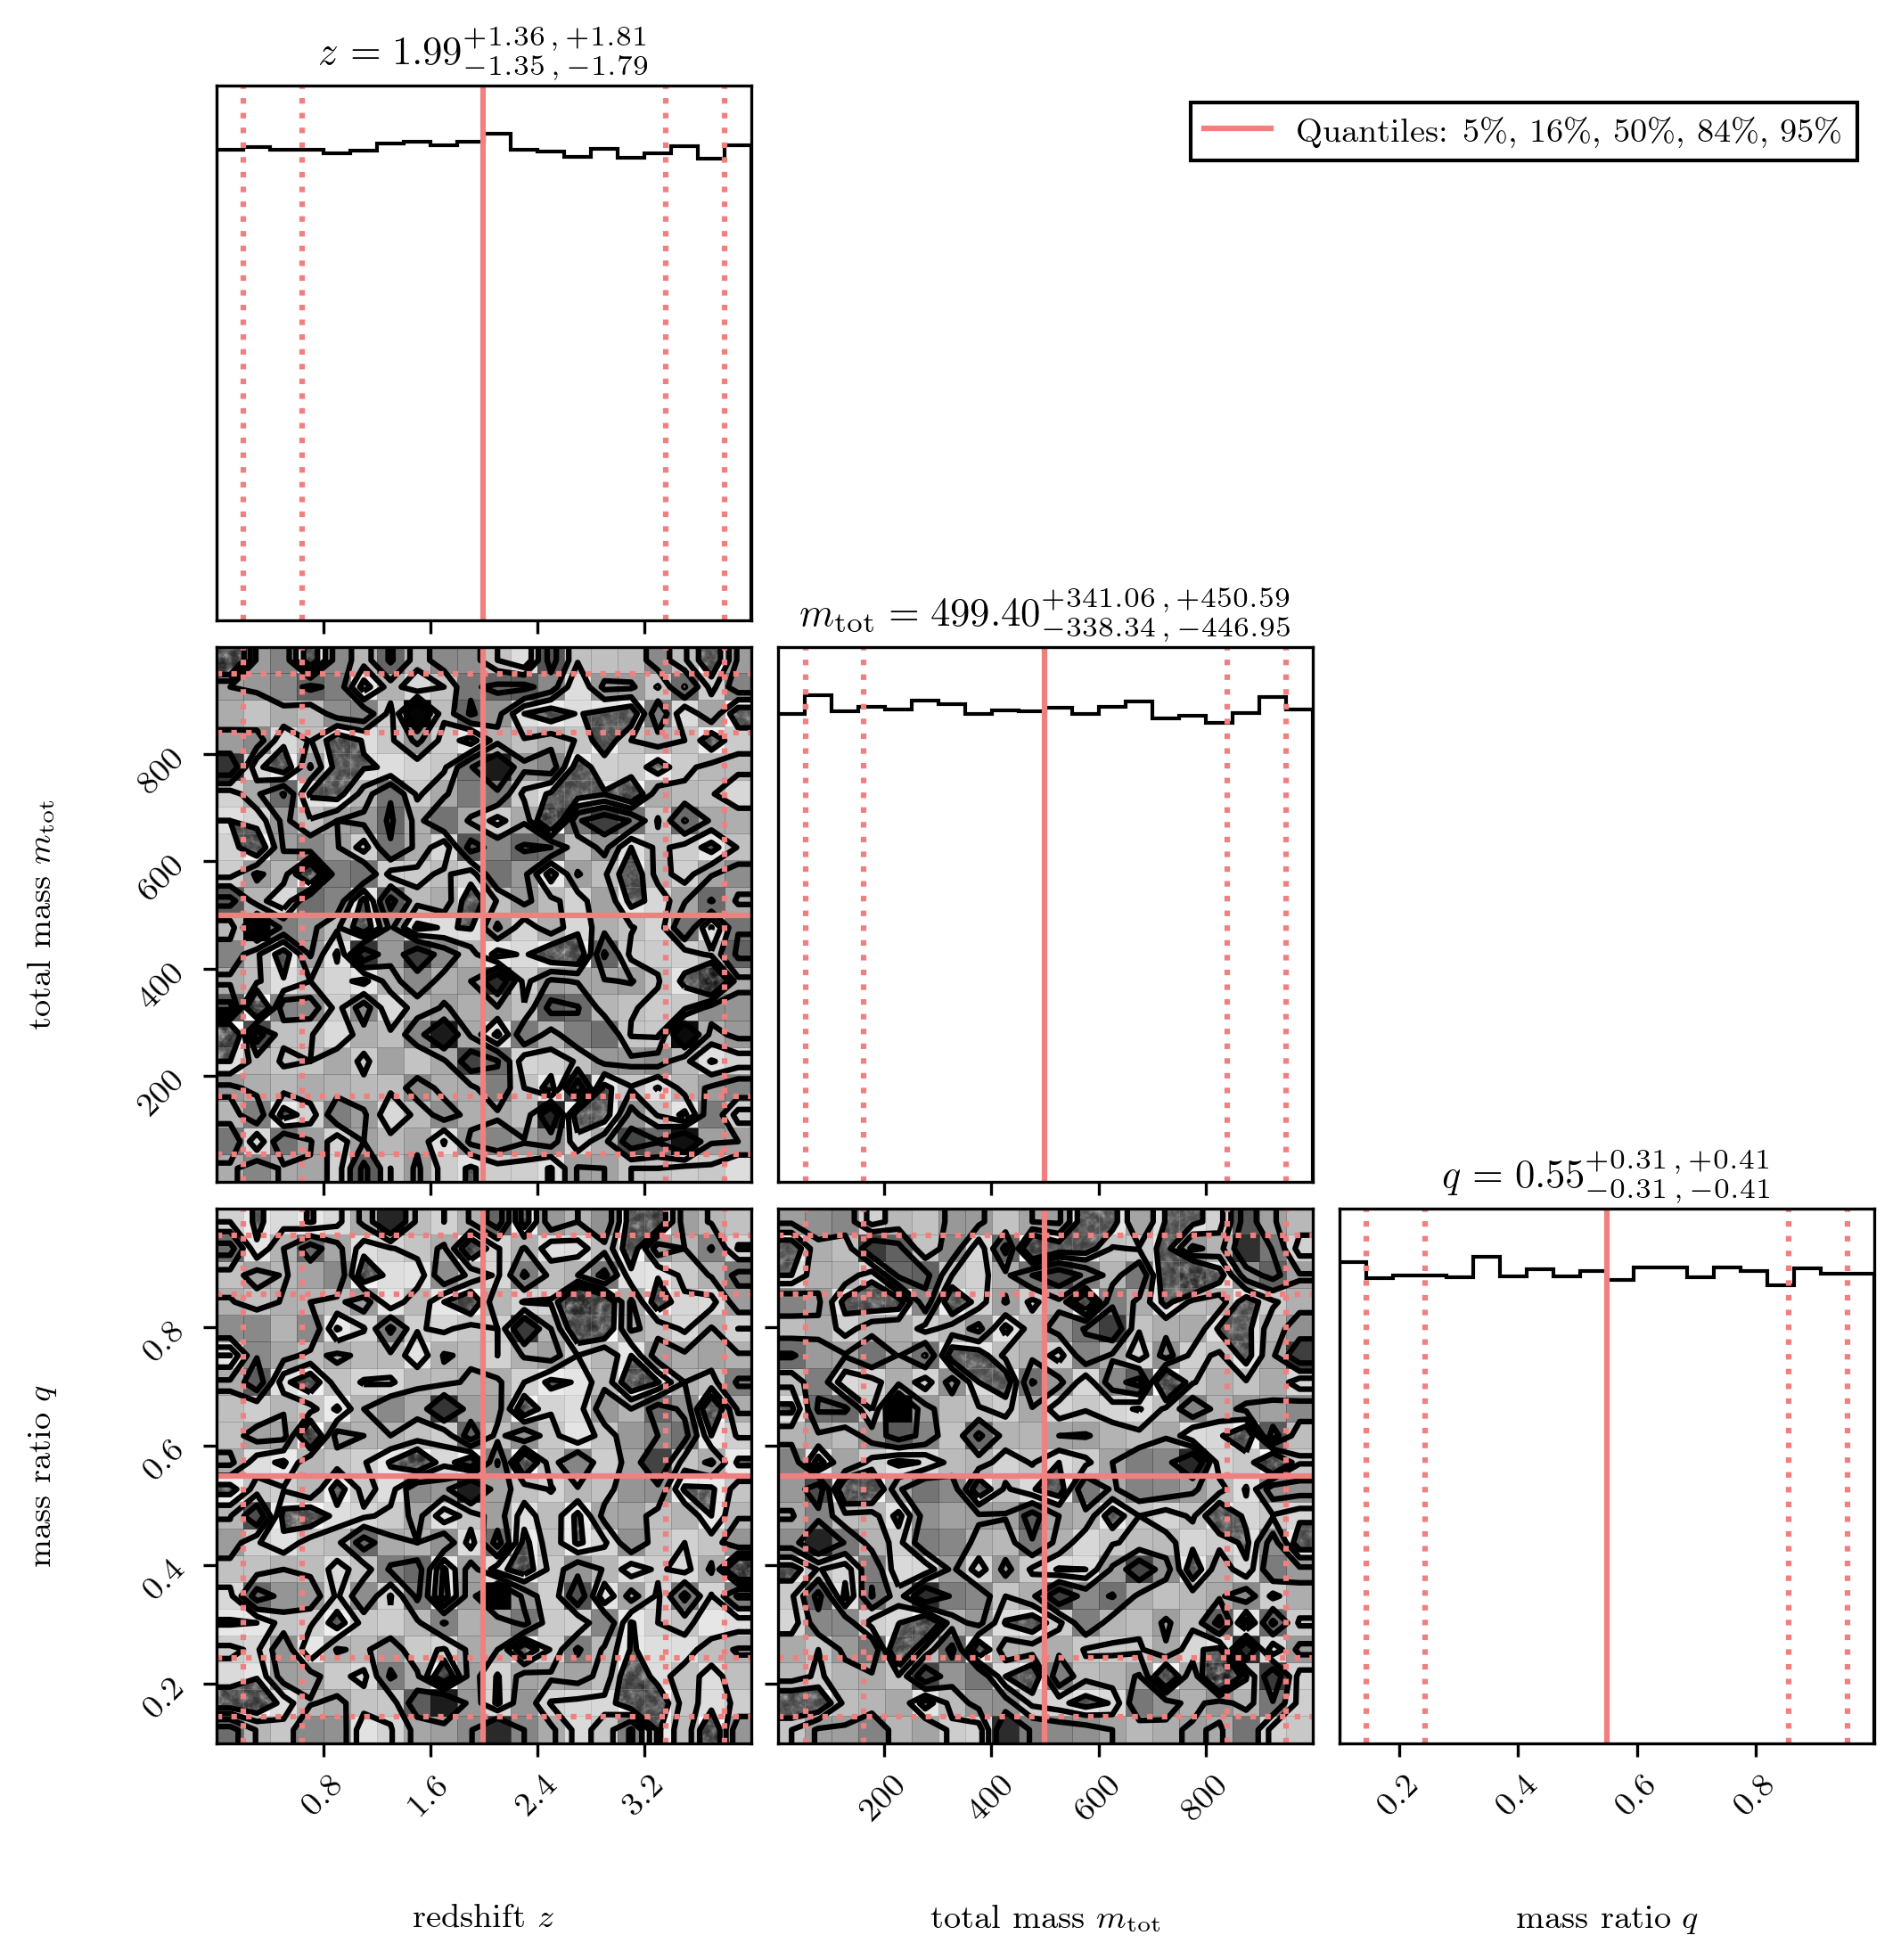

In [7]:
#-------------------------------------------------------------------------
# Quick data visualization
#-------------------------------------------------------------------------

fontsize = 9

axlabels = [r'redshift $z$', r'total mass $m_{\rm tot}$', r'mass ratio $q$']

fig = corner.corner(
    x_debug,
    labels=axlabels,
    verbose      = False,
    show_titles  = False,
    title_kwargs = {'fontsize':fontsize},
    label_kwargs = {'fontsize':fontsize}
    # range        = lims
)
n_dim = 3
ax = np.array(fig.axes).reshape((n_dim, n_dim))

quantiles = np.zeros((5,n_dim))
for i in range(n_dim):
    quantiles[:,i] = corner.quantile(x_debug[:,i], q=[0.05, 0.16, 0.5, 0.84, 0.95])

ax[0,n_dim-1].plot([], [], marker='', color='lightcoral', label='Quantiles: 5\%, 16\%, 50\%, 84\%, 95\%')

corner.overplot_lines(fig, quantiles[2,:], color="lightcoral")
corner.overplot_lines(fig, quantiles[0,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles[1,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles[3,:], color="lightcoral", ls=':')
corner.overplot_lines(fig, quantiles[4,:], color="lightcoral", ls=':')

par_name = [r'z', r'm_{\rm tot}', r'q']
for i in range(n_dim):
    titles = '$' + par_name[i] + '=' + \
             '{:.2f}'.format(quantiles[2,i]) + r'^{+' + \
             '{:.2f}'.format(quantiles[3,i] - quantiles[2,i]) + r'\, , \,+' + \
             '{:.2f}'.format(quantiles[4,i] - quantiles[2,i]) + r'}_{-'      + \
             '{:.2f}'.format(quantiles[2,i] - quantiles[1,i]) + r'\, , \,-'  + \
             '{:.2f}'.format(quantiles[2,i] - quantiles[0,i]) + r'}$'
    ax[i,i].set_title( titles )

ax[0,n_dim-1].legend(title_fontsize=fontsize, fontsize=fontsize, frameon=True, framealpha=1, fancybox=False, edgecolor='black')

if False:
    fig.savefig('./L20_images/L20_dataset_cornerplot.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_dataset_cornerplot.png', bbox_inches='tight')

del fig
del ax

#-------------------------------------------------------------------------

# Split the dataset into training and validation

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=9)

# Another quick visualization of the param space $\big( z - m_{\rm tot} - q \big)$

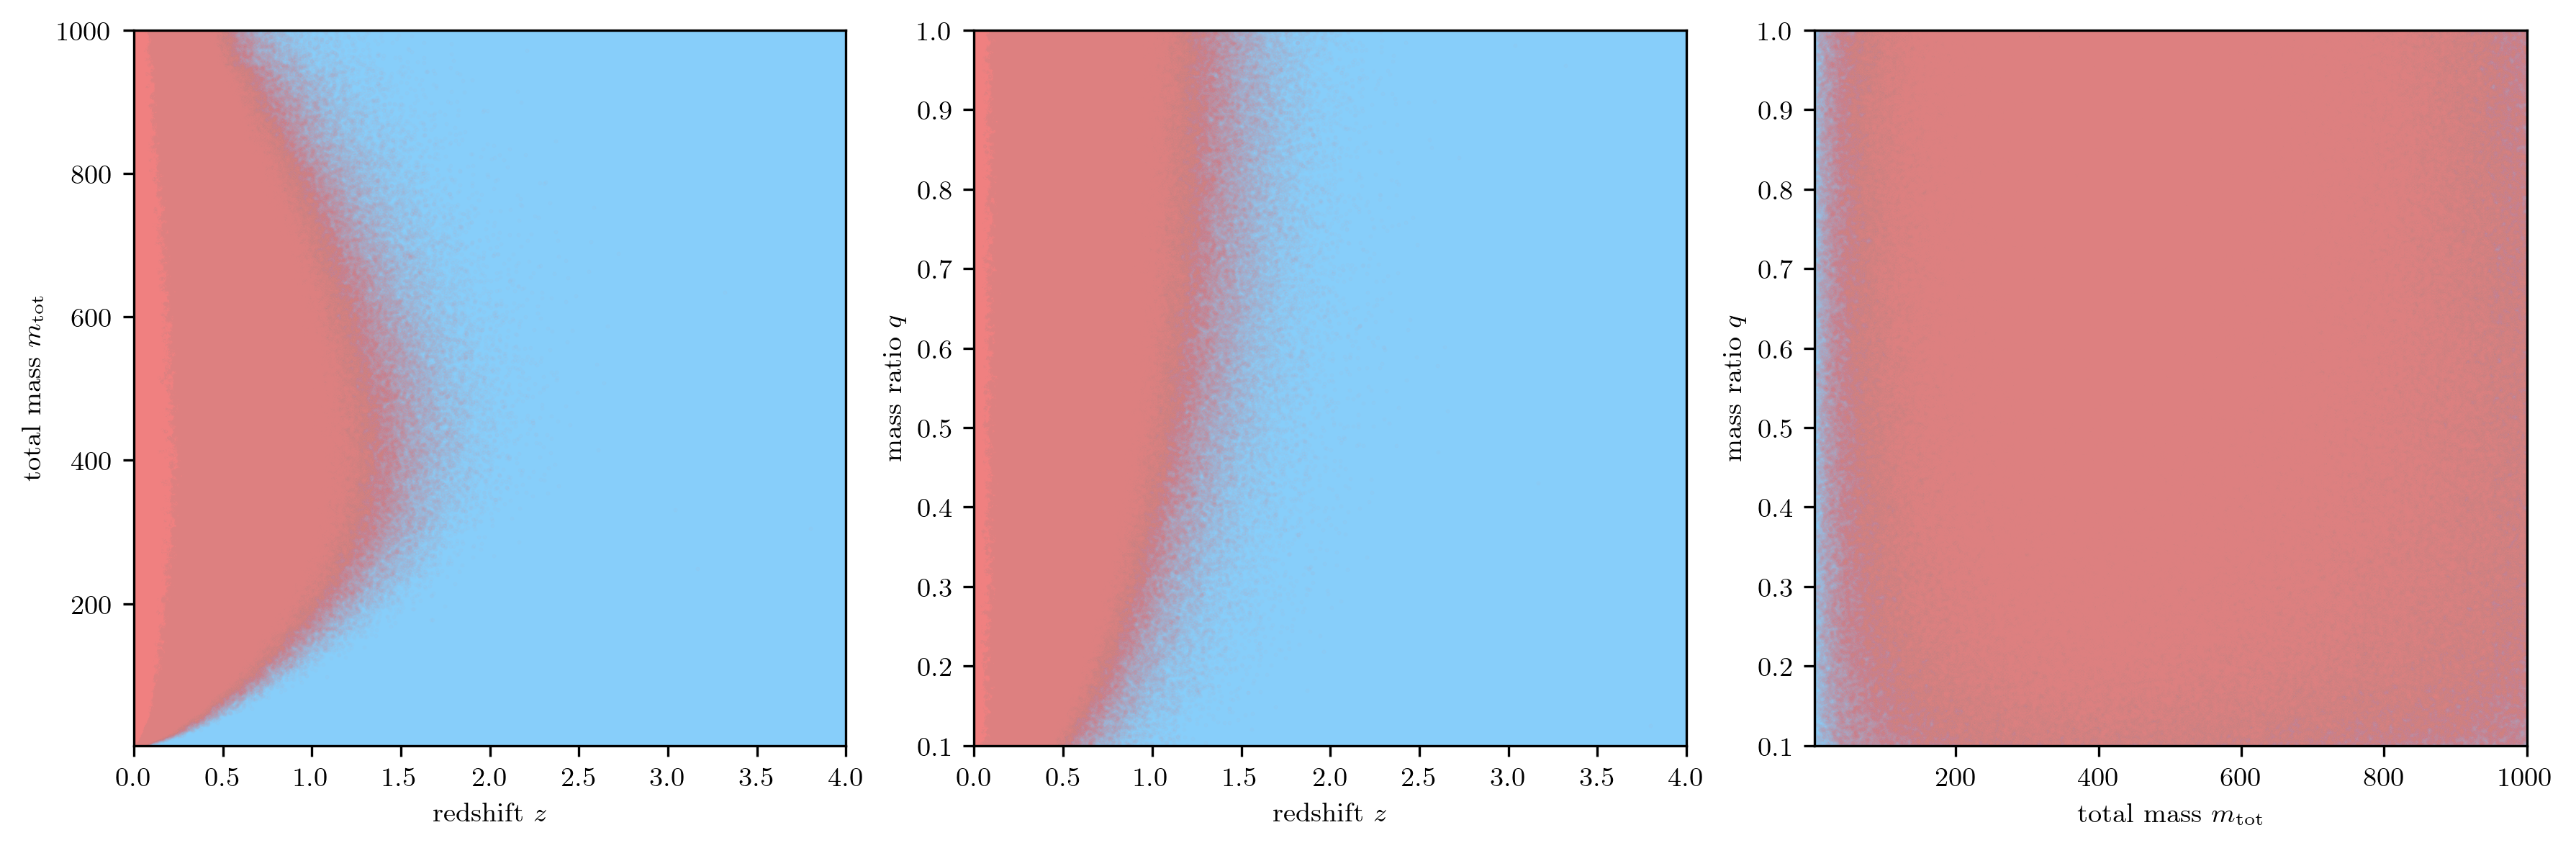

In [9]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(12,4))

lims = [(0,4),(2,1000),(0.1,1.0)]

# x0 = z ; x1 = m_tot
ax[0].set_xlim(lims[0])
ax[0].set_ylim(lims[1])
ax[0].set_xlabel(axlabels[0])
ax[0].set_ylabel(axlabels[1])
ax[0].scatter(x[index_det_n,0] , x[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
ax[0].scatter(x[index_det_y,0] , x[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

# x0 = z ; x2 = q
ax[1].set_xlim(lims[0])
ax[1].set_ylim(lims[2])
ax[1].set_xlabel(axlabels[0])
ax[1].set_ylabel(axlabels[2])
ax[1].scatter(x[index_det_n,0] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
ax[1].scatter(x[index_det_y,0] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

# x1 = m_tot ; x2 = q
ax[2].set_xlim(lims[1])
ax[2].set_ylim(lims[2])
ax[2].set_xlabel(axlabels[1])
ax[2].set_ylabel(axlabels[2])
ax[2].scatter(x[index_det_n,1] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
ax[2].scatter(x[index_det_y,1] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

fig.tight_layout()

if False:
    fig.savefig('./L20_images/L20_dataset_scatterplot.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_dataset_scatterplot.png', bbox_inches='tight')

del fig
del ax

#-------------------------------------------------------------------------

# Exploration with weak classifier (QDA) - accuracy $\sim 93\%$

In [10]:
#-------------------------------------------------------------------------
# Quadratic Discriminant Analysis classifier, define it
#-------------------------------------------------------------------------

def compute_QDA_list(N_features, x_train, y_train, x_test, y_test):

    clf_           = []
    y_pred_        = []
    completeness_  = []
    contamination_ = []
    accuracy_      = []
    roc_fpr_       = []
    roc_tpr_       = []
    roc_auc_       = []

    for f_max in N_features:

        clf = QDA()

        clf.fit(x_train[:, :f_max], y_train)
        clf_.append(clf)

        y_prob = clf.predict_proba(x_test[:, :f_max])
        y_pred = clf.predict(x_test[:, :f_max])
        y_pred_.append(y_pred)

        completeness, contamination = completeness_contamination(y_pred, y_test)
        accuracy = accuracy_score(y_test, y_pred)
        completeness_.append(completeness)
        contamination_.append(contamination)
        accuracy_.append(accuracy)

        roc_fpr , roc_tpr, roc_tresh = roc_curve(y_test, y_prob[:,1])
        roc_auc = roc_auc_score(y_test, y_prob[:,1])
        roc_fpr_.append(roc_fpr)
        roc_tpr_.append(roc_tpr)
        roc_auc_.append(roc_auc)

    return clf_, completeness_, contamination_, accuracy_, roc_fpr_, roc_tpr_, roc_auc_

In [11]:
#-------------------------------------------------------------------------
# Run the QDA classifier
#-------------------------------------------------------------------------

x_train_QDA = x_train
x_test_QDA  = x_test
y_train_QDA = y_train
y_test_QDA  = y_test

N_colors_QDA = [2,3]

classifiers_QDA,  \
completeness_QDA, \
contamination_QDA,\
accuracy_QDA,     \
roc_fpr_QDA,      \
roc_tpr_QDA,      \
roc_auc_QDA,      \
= compute_QDA_list(
    N_colors_QDA, 
    x_train_QDA, 
    y_train_QDA, 
    x_test_QDA, 
    y_test_QDA
)

#-------------------------------------------------------------------------

In [12]:
print(
'Method: QDA with z, m_tot \n\
completeness:  {:.3f} \n\
contamination: {:.3f} \n\
accuracy:      {:.3f}'.format(completeness_QDA[0], contamination_QDA[0], accuracy_QDA[0])
)
print()
print(
'Method: QDA with z, m_tot, q \n\
completeness:  {:.3f} \n\
contamination: {:.3f} \n\
accuracy:      {:.3f}'.format(completeness_QDA[1], contamination_QDA[1], accuracy_QDA[1])
)

Method: QDA with z, m_tot 
completeness:  0.870 
contamination: 0.292 
accuracy:      0.929

Method: QDA with z, m_tot, q 
completeness:  0.876 
contamination: 0.278 
accuracy:      0.934


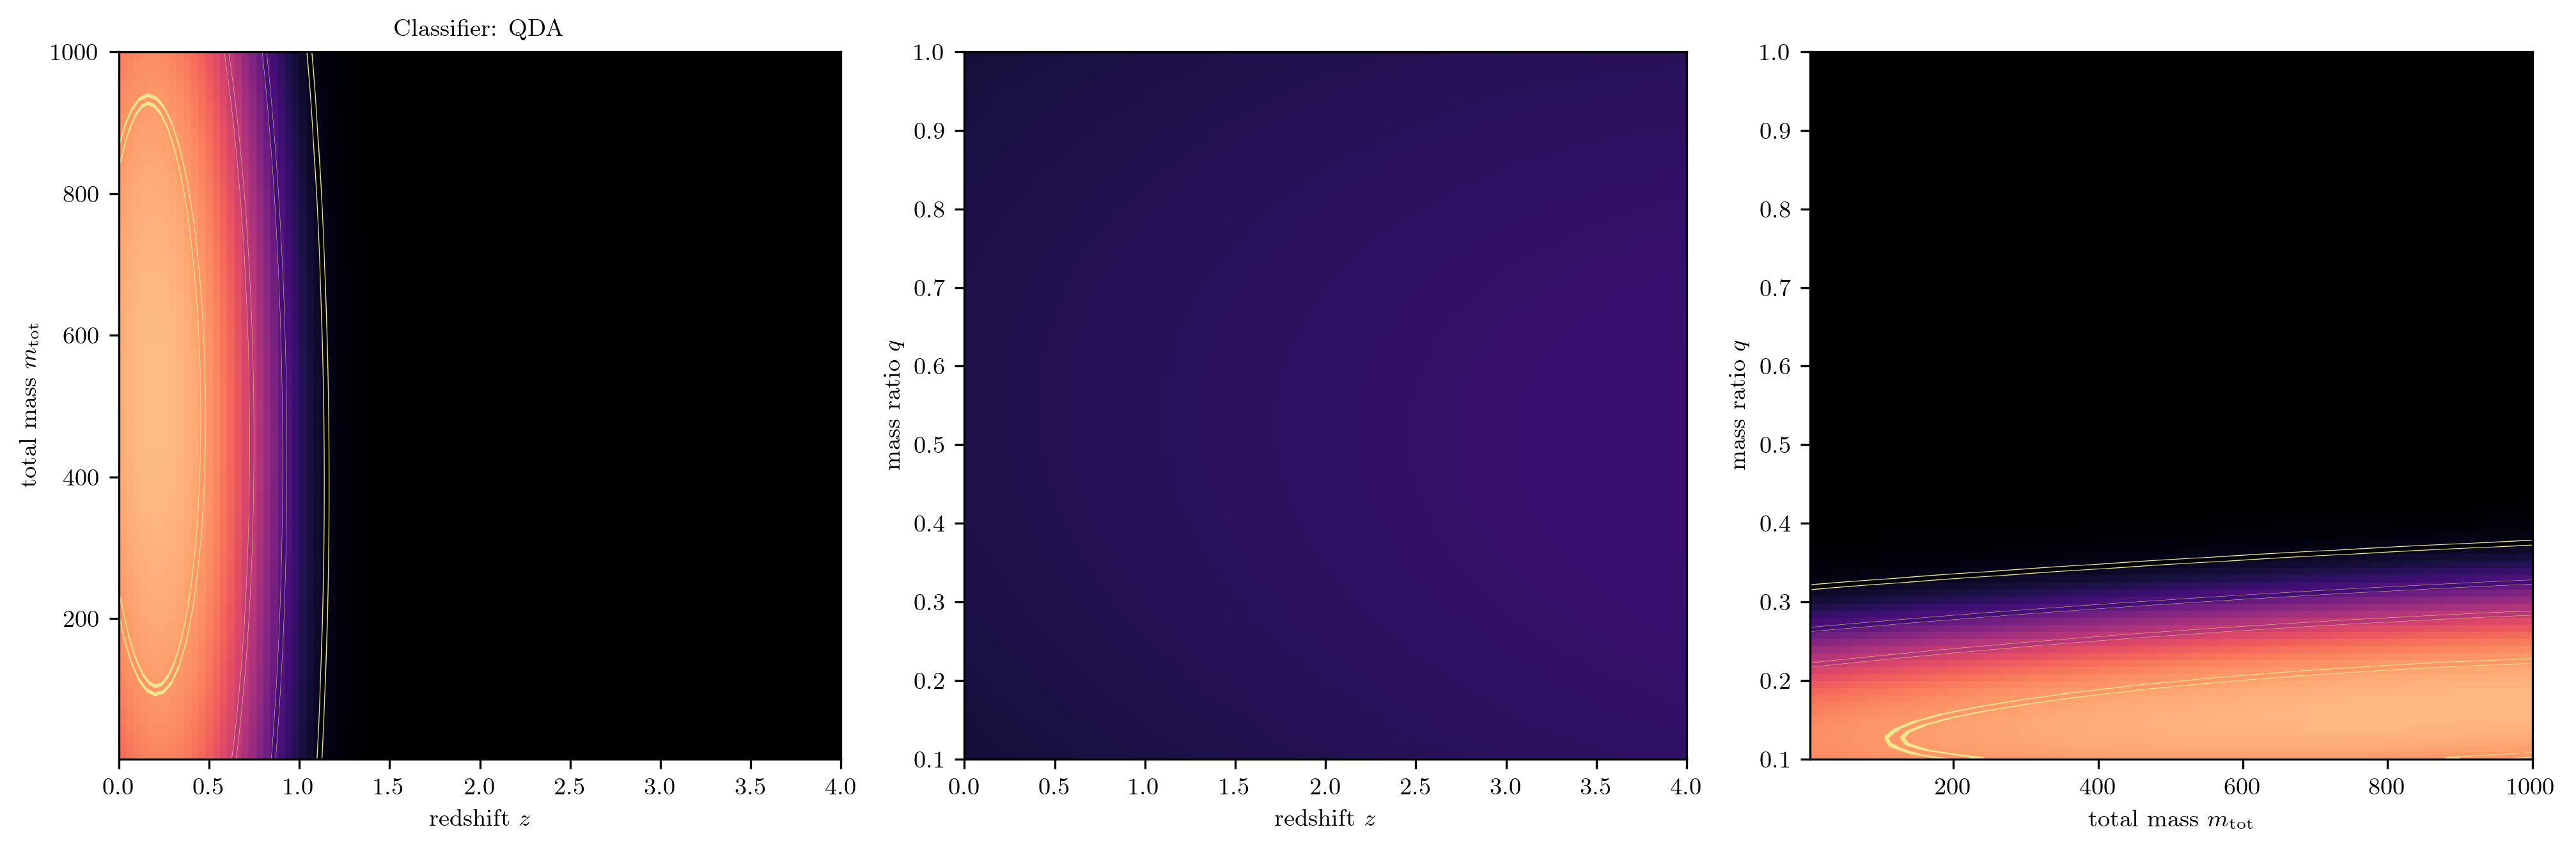

In [ ]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(4.5*3,4.5))

#-------------------------------------------------------------------------

N_grid = 100
x0, x1, x2 = np.meshgrid(
    np.linspace(lims[0][0], lims[0][1], N_grid),
    np.linspace(lims[1][0], lims[1][1], N_grid),
    np.linspace(lims[2][0], lims[2][1], N_grid)
)

yy_QDA = classifiers_QDA[1].predict_proba(np.c_[x0.ravel(), x1.ravel(), x2.ravel()])
yy_QDA = yy_QDA[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims[0][0], lims[0][1], N_grid)
xb = np.linspace(lims[1][0], lims[1][1], N_grid)
py = yy_QDA.sum(axis=2)/N_grid
ax[0].contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax[0].contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
# im = ax[0].imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[0]+lims[1])
im = ax[0].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[1])

# x0 = z ; x2 = q
xa = np.linspace(lims[0][0], lims[0][1], N_grid)
xb = np.linspace(lims[2][0], lims[2][1], N_grid)
py = yy_QDA.sum(axis=1)/N_grid
ax[1].contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax[1].contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
im = ax[1].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[2])

# x1 = m_tot ; x2 = q
xa = np.linspace(lims[1][0], lims[1][1], N_grid)
xb = np.linspace(lims[2][0], lims[2][1], N_grid)
py = yy_QDA.sum(axis=0)/N_grid
ax[2].contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax[2].contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
im = ax[2].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[1]+lims[2])

#-------------------------------------------------------------------------
# plot also the data

# x0 = z ; x1 = m_tot
ax[0].set_xlim(lims[0])
ax[0].set_ylim(lims[1])
ax[0].set_xlabel(axlabels[0])
ax[0].set_ylabel(axlabels[1])
# ax[0].scatter(x[index_det_n,0] , x[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[0].scatter(x[index_det_y,0] , x[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

# x0 = z ; x2 = q
ax[1].set_xlim(lims[0])
ax[1].set_ylim(lims[2])
ax[1].set_xlabel(axlabels[0])
ax[1].set_ylabel(axlabels[2])
# ax[1].scatter(x[index_det_n,0] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[1].scatter(x[index_det_y,0] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

# x1 = m_tot ; x2 = q
ax[2].set_xlim(lims[1])
ax[2].set_ylim(lims[2])
ax[2].set_xlabel(axlabels[1])
ax[2].set_ylabel(axlabels[2])
# ax[2].scatter(x[index_det_n,1] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[2].scatter(x[index_det_y,1] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

# fig.suptitle('Classifier: QDA')
ax[0].set_title('Classifier: QDA', fontsize=9)

fig.tight_layout()

if False:
    fig.savefig('./L20_images/L20_classifier_QDA_Nfeats=3.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_QDA_Nfeats=3.png', bbox_inches='tight')

del fig
del ax

#-------------------------------------------------------------------------

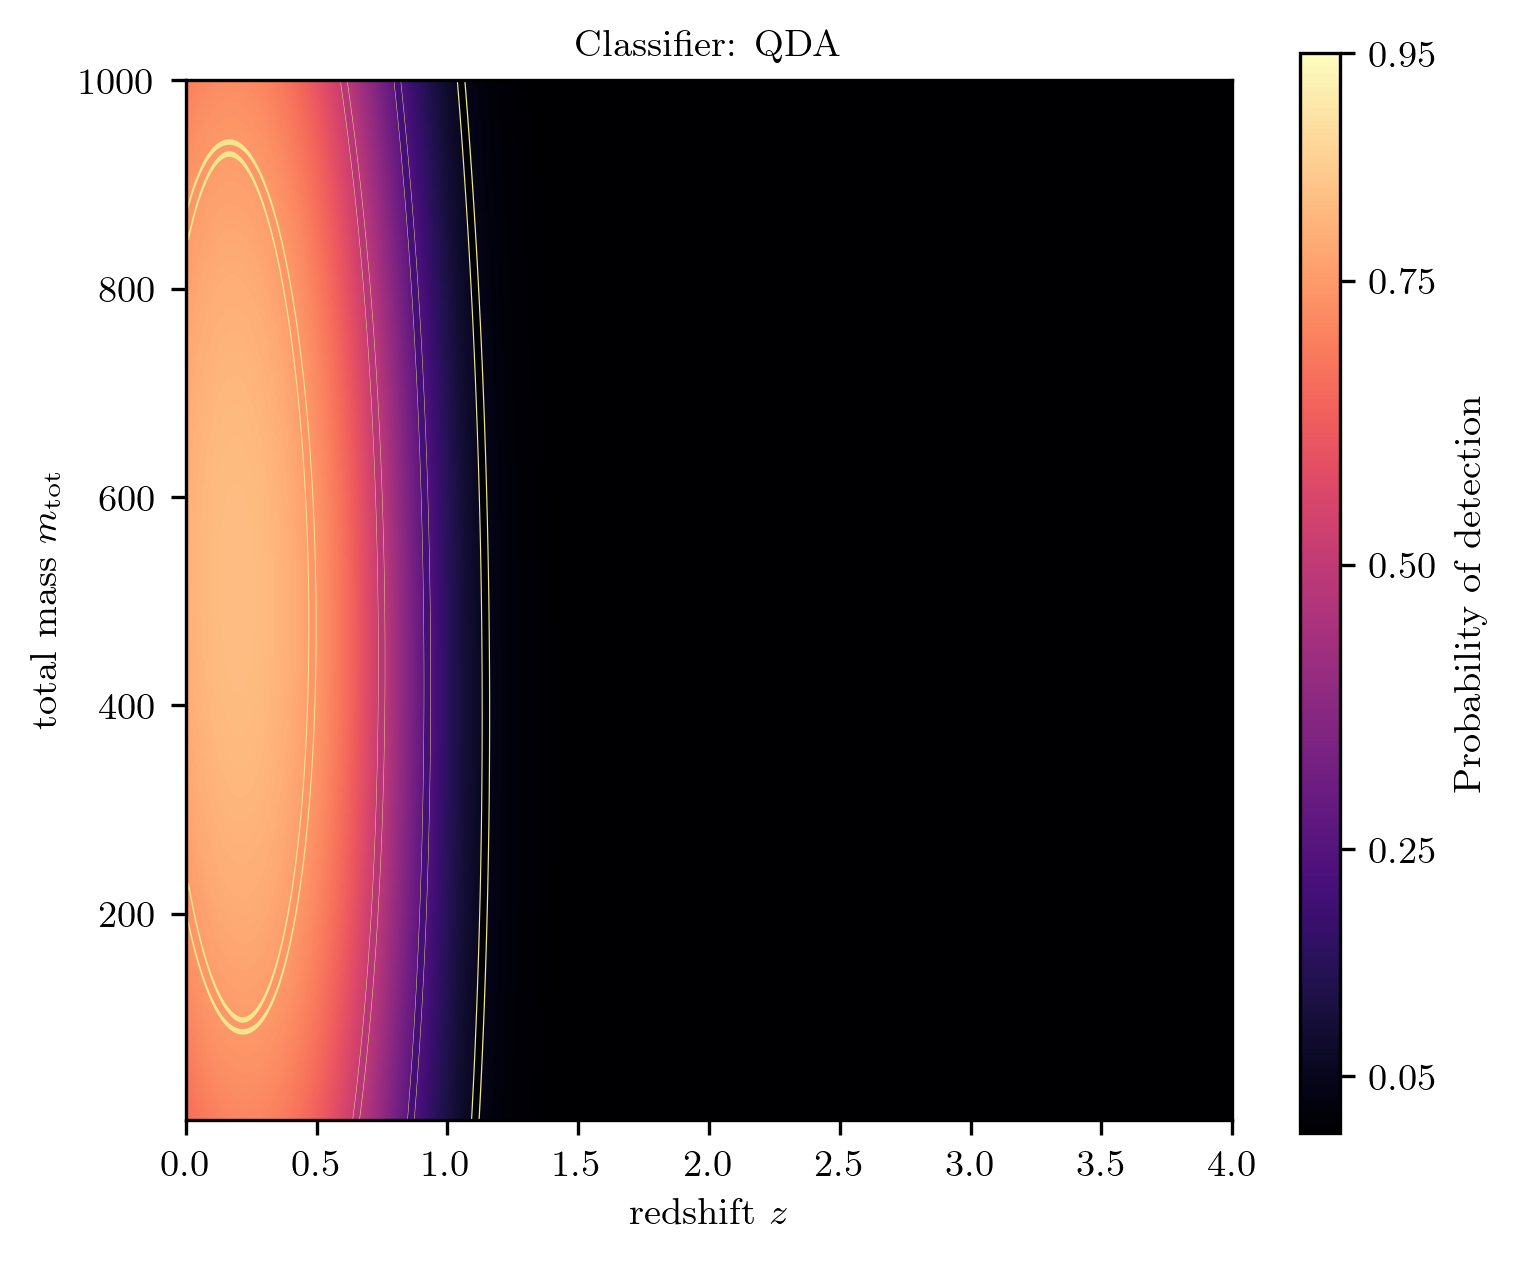

In [ ]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(4.5,4.5))

#-------------------------------------------------------------------------

x0, x1 = np.meshgrid(
    np.linspace(lims[0][0], lims[0][1], 500),
    np.linspace(lims[1][0], lims[1][1], 500)
)

yy_QDA = classifiers_QDA[0].predict_proba(np.c_[x0.ravel(), x1.ravel()])
yy_QDA = yy_QDA[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims[0][0], lims[0][1], 500)
xb = np.linspace(lims[1][0], lims[1][1], 500)
py = yy_QDA
ax.contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax.contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
# im = ax.imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[0]+lims[1])
im = ax.imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[1])
cmapax = fig.add_axes([0.95, 0.1, 0.03, 0.8])
# cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, spacing='proportional', ticks=cmap_ticks, boundaries=cmap_bounds, format='%.2f') # %.1f
cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, ticks=cmap_ticks, format='%.2f')
cmapax.set_ylabel('Probability of detection')

#-------------------------------------------------------------------------
# plot also the data

ax.set_xlim(lims[0])
ax.set_ylim(lims[1])
ax.set_xlabel(axlabels[0])
ax.set_ylabel(axlabels[1])
# ax.scatter(x[index_det_n,0] , x[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax.scatter(x[index_det_y,0] , x[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax.set_title('Classifier: QDA ', fontsize=9)

if False:
    fig.savefig('./L20_images/L20_classifier_QDA_Nfeats=2.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_QDA_Nfeats=2.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

# Exploration with weak classifier (GMM) - accuracy $\sim 94\%$

In [15]:
#-------------------------------------------------------------------------
# GMM Bayes classifier, define it
#-------------------------------------------------------------------------

@pickle_results('L20_GMMbayes_1to3.pkl')
def compute_GMMBayes_list(N_features, N_comp, x_train, y_train, x_test, y_test):

    classifiers    = []
    y_pred_        = []
    completeness_  = []
    contamination_ = []
    accuracy_      = []
    roc_fpr_       = []
    roc_tpr_       = []
    roc_auc_       = []

    for component in N_comp:

        classifiers.append([])
        y_pred_.append([])
        completeness_.append([])
        contamination_.append([])
        accuracy_.append([])
        roc_fpr_.append([])
        roc_tpr_.append([])
        roc_auc_.append([])

        for f_max in N_features:

            clf = GMMBayes(component, tol=1E-5, covariance_type='full')

            clf.fit(x_train[:, :f_max], y_train)
            classifiers[-1].append(clf)

            y_prob = clf.predict_proba(x_test[:, :f_max])
            y_pred = clf.predict(x_test[:, :f_max])

            completeness, contamination = completeness_contamination(y_pred, y_test)
            accuracy = accuracy_score(y_test, y_pred)
            completeness_[-1].append(completeness)
            contamination_[-1].append(contamination)
            accuracy_[-1].append(accuracy)

            roc_fpr , roc_tpr, roc_tresh = roc_curve(y_test, y_prob[:,1])
            roc_auc = roc_auc_score(y_test, y_prob[:,1])
            roc_fpr_[-1].append(roc_fpr)
            roc_tpr_[-1].append(roc_tpr)
            roc_auc_[-1].append(roc_auc)

            print('{:d} components, {:d} features:  done!'.format(component, f_max))
            print('   completeness:  {:.3f}'.format(completeness))
            print('   contamination: {:.3f}'.format(contamination))
            print('   accuracy:      {:.3f}'.format(accuracy))

    return classifiers, completeness_, contamination_, accuracy_, roc_fpr_, roc_tpr_, roc_auc_

#-------------------------------------------------------------------------

In [16]:
#-------------------------------------------------------------------------
# Run the GMM Bayes classifier
#-------------------------------------------------------------------------

x_train_GMMBayes = x_train 
x_test_GMMBayes  = x_test
y_train_GMMBayes = y_train 
y_test_GMMBayes  = y_test

N_colors_GMMBayes = [2,3]
N_comp_GMMBayes   = np.arange(1,4)

classifiers_GMMBayes,  \
completeness_GMMBayes, \
contamination_GMMBayes,\
accuracy_GMMBayes,     \
roc_fpr_GMMBayes,      \
roc_tpr_GMMBayes,      \
roc_auc_GMMBayes,      \
= compute_GMMBayes_list(
    N_colors_GMMBayes, 
    N_comp_GMMBayes,
    x_train_GMMBayes, 
    y_train_GMMBayes, 
    x_test_GMMBayes, 
    y_test_GMMBayes
)

#-------------------------------------------------------------------------

@pickle_results: computing results and saving to 'L20_GMMbayes_1to3.pkl'
1 components, 2 features:  done!
   completeness:  0.870
   contamination: 0.292
   accuracy:      0.929
1 components, 3 features:  done!
   completeness:  0.876
   contamination: 0.278
   accuracy:      0.934


c:\Users\andre\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


2 components, 2 features:  done!
   completeness:  0.825
   contamination: 0.215
   accuracy:      0.942
2 components, 3 features:  done!
   completeness:  0.833
   contamination: 0.196
   accuracy:      0.947
3 components, 2 features:  done!
   completeness:  0.847
   contamination: 0.221
   accuracy:      0.943
3 components, 3 features:  done!
   completeness:  0.852
   contamination: 0.200
   accuracy:      0.948


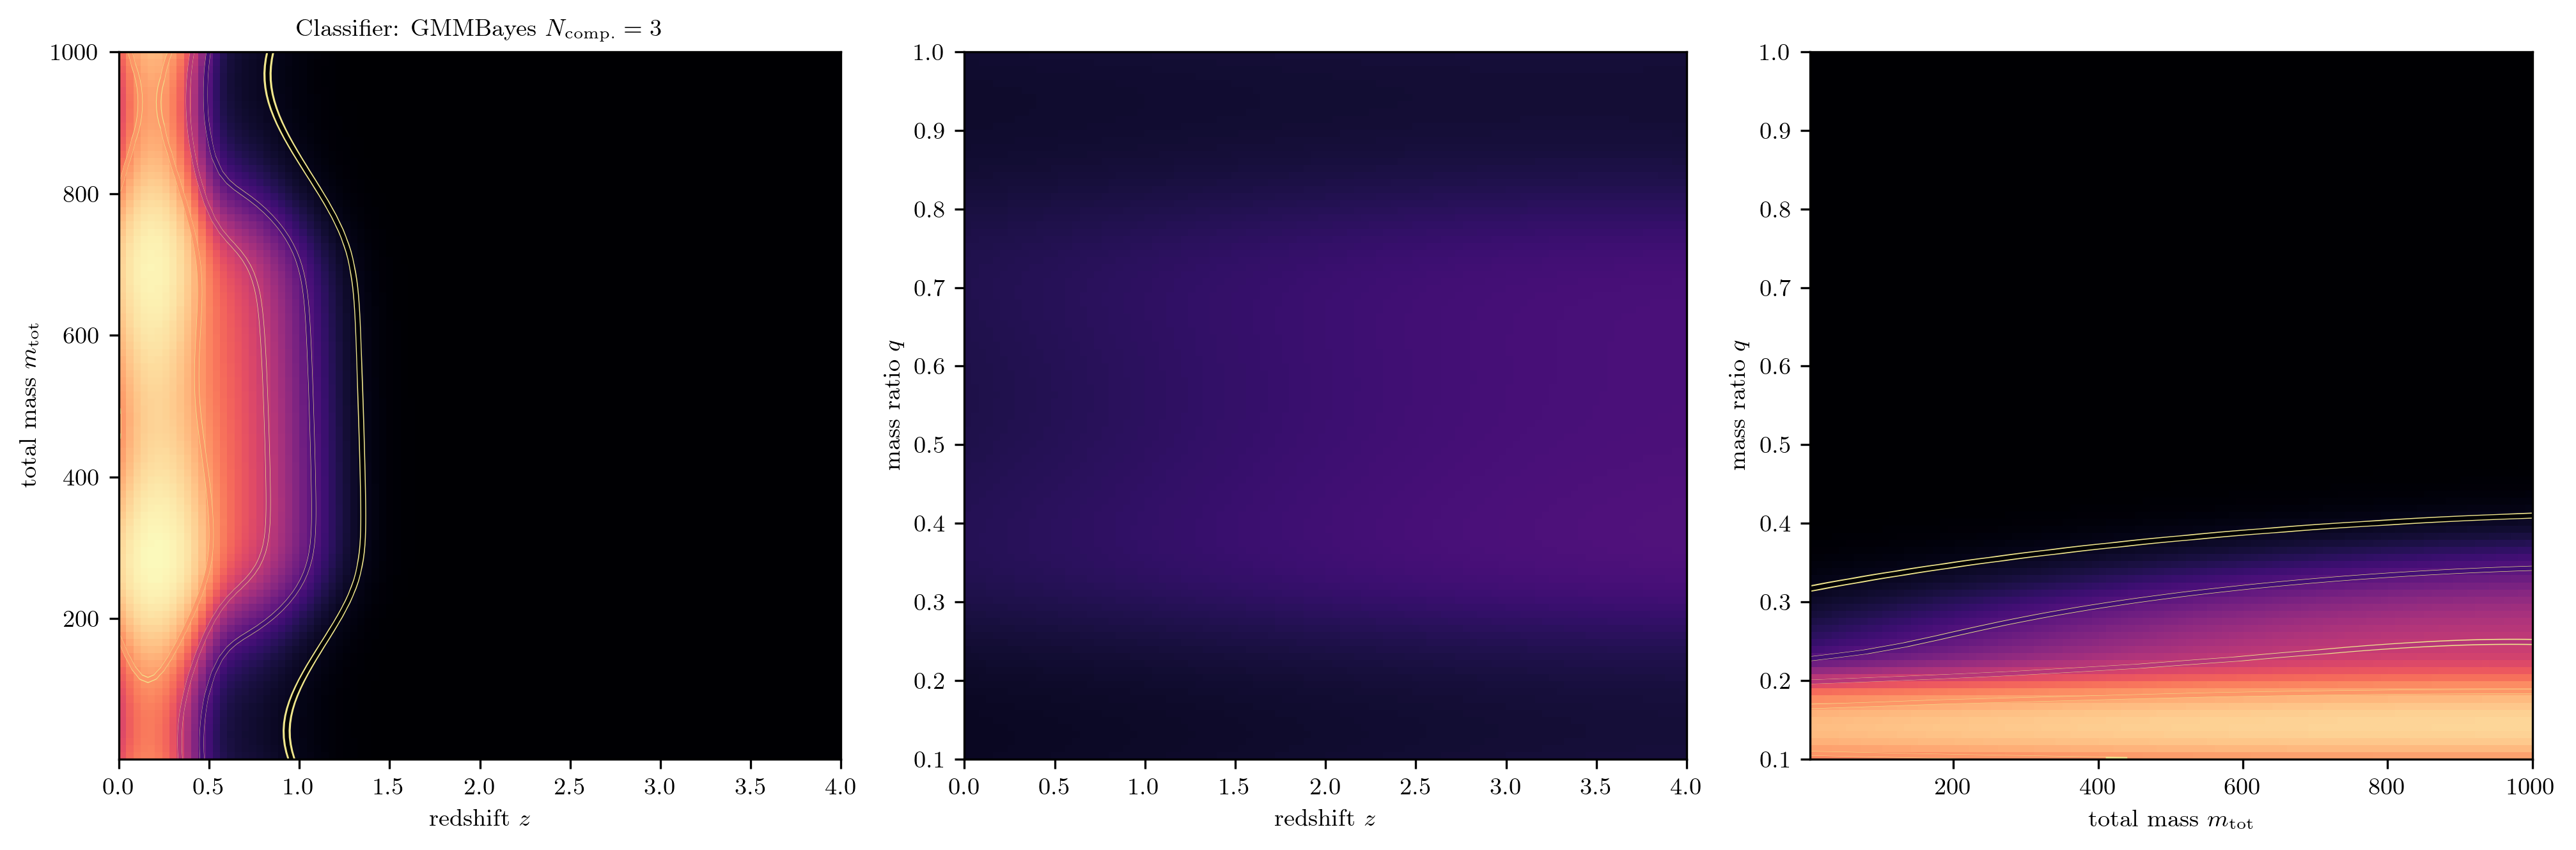

In [17]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(4.5*3,4.5))

#-------------------------------------------------------------------------

x0, x1, x2 = np.meshgrid(
    np.linspace(lims[0][0], lims[0][1], 100),
    np.linspace(lims[1][0], lims[1][1], 100),
    np.linspace(lims[2][0], lims[2][1], 100)
)

yy_GMMBayes = classifiers_GMMBayes[2][-1].predict_proba(np.c_[x0.ravel(), x1.ravel(), x2.ravel()])
yy_GMMBayes = yy_GMMBayes[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims[0][0], lims[0][1], 100)
xb = np.linspace(lims[1][0], lims[1][1], 100)
py = yy_GMMBayes.sum(axis=2)/100
ax[0].contour(xa, xb, py, contours+0.002, colors='khaki')
ax[0].contour(xa, xb, py, contours-0.002, colors='khaki')
ax[0].contour(xa, xb, py, contours, cmap=cmap)
# im = ax[0].imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[0]+lims[1])
im = ax[0].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[1])


# x0 = z ; x2 = q
xa = np.linspace(lims[0][0], lims[0][1], 100)
xb = np.linspace(lims[2][0], lims[2][1], 100)
py = yy_GMMBayes.sum(axis=1)/100
ax[1].contour(xa, xb, py, contours+0.002, colors='khaki')
ax[1].contour(xa, xb, py, contours-0.002, colors='khaki')
ax[1].contour(xa, xb, py, contours, cmap=cmap)
im = ax[1].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[2])

# x1 = m_tot ; x2 = q
xa = np.linspace(lims[1][0], lims[1][1], 100)
xb = np.linspace(lims[2][0], lims[2][1], 100)
py = yy_GMMBayes.sum(axis=0)/100
ax[2].contour(xa, xb, py, contours+0.002, colors='khaki')
ax[2].contour(xa, xb, py, contours-0.002, colors='khaki')
ax[2].contour(xa, xb, py, contours, cmap=cmap)
im = ax[2].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[1]+lims[2])

#-------------------------------------------------------------------------
# plot also the data


ax[0].set_xlim(lims[0])
ax[0].set_ylim(lims[1])
ax[0].set_xlabel(axlabels[0])
ax[0].set_ylabel(axlabels[1])
# ax[0].scatter(x[index_det_n,0] , x[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[0].scatter(x[index_det_y,0] , x[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax[1].set_xlim(lims[0])
ax[1].set_ylim(lims[2])
ax[1].set_xlabel(axlabels[0])
ax[1].set_ylabel(axlabels[2])
# ax[1].scatter(x[index_det_n,0] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[1].scatter(x[index_det_y,0] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

ax[2].set_xlim(lims[1])
ax[2].set_ylim(lims[2])
ax[2].set_xlabel(axlabels[1])
ax[2].set_ylabel(axlabels[2])
# ax[2].scatter(x[index_det_n,1] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[2].scatter(x[index_det_y,1] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

ax[0].set_title('Classifier: GMMBayes ' + r'$N_{\rm comp.} = 3$', fontsize=9)

fig.tight_layout()

if False:
    fig.savefig('./L20_images/L20_classifier_GMMBayes_Ncomps=3_Nfeats=3.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_GMMBayes_Ncomps=3_Nfeats=3.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

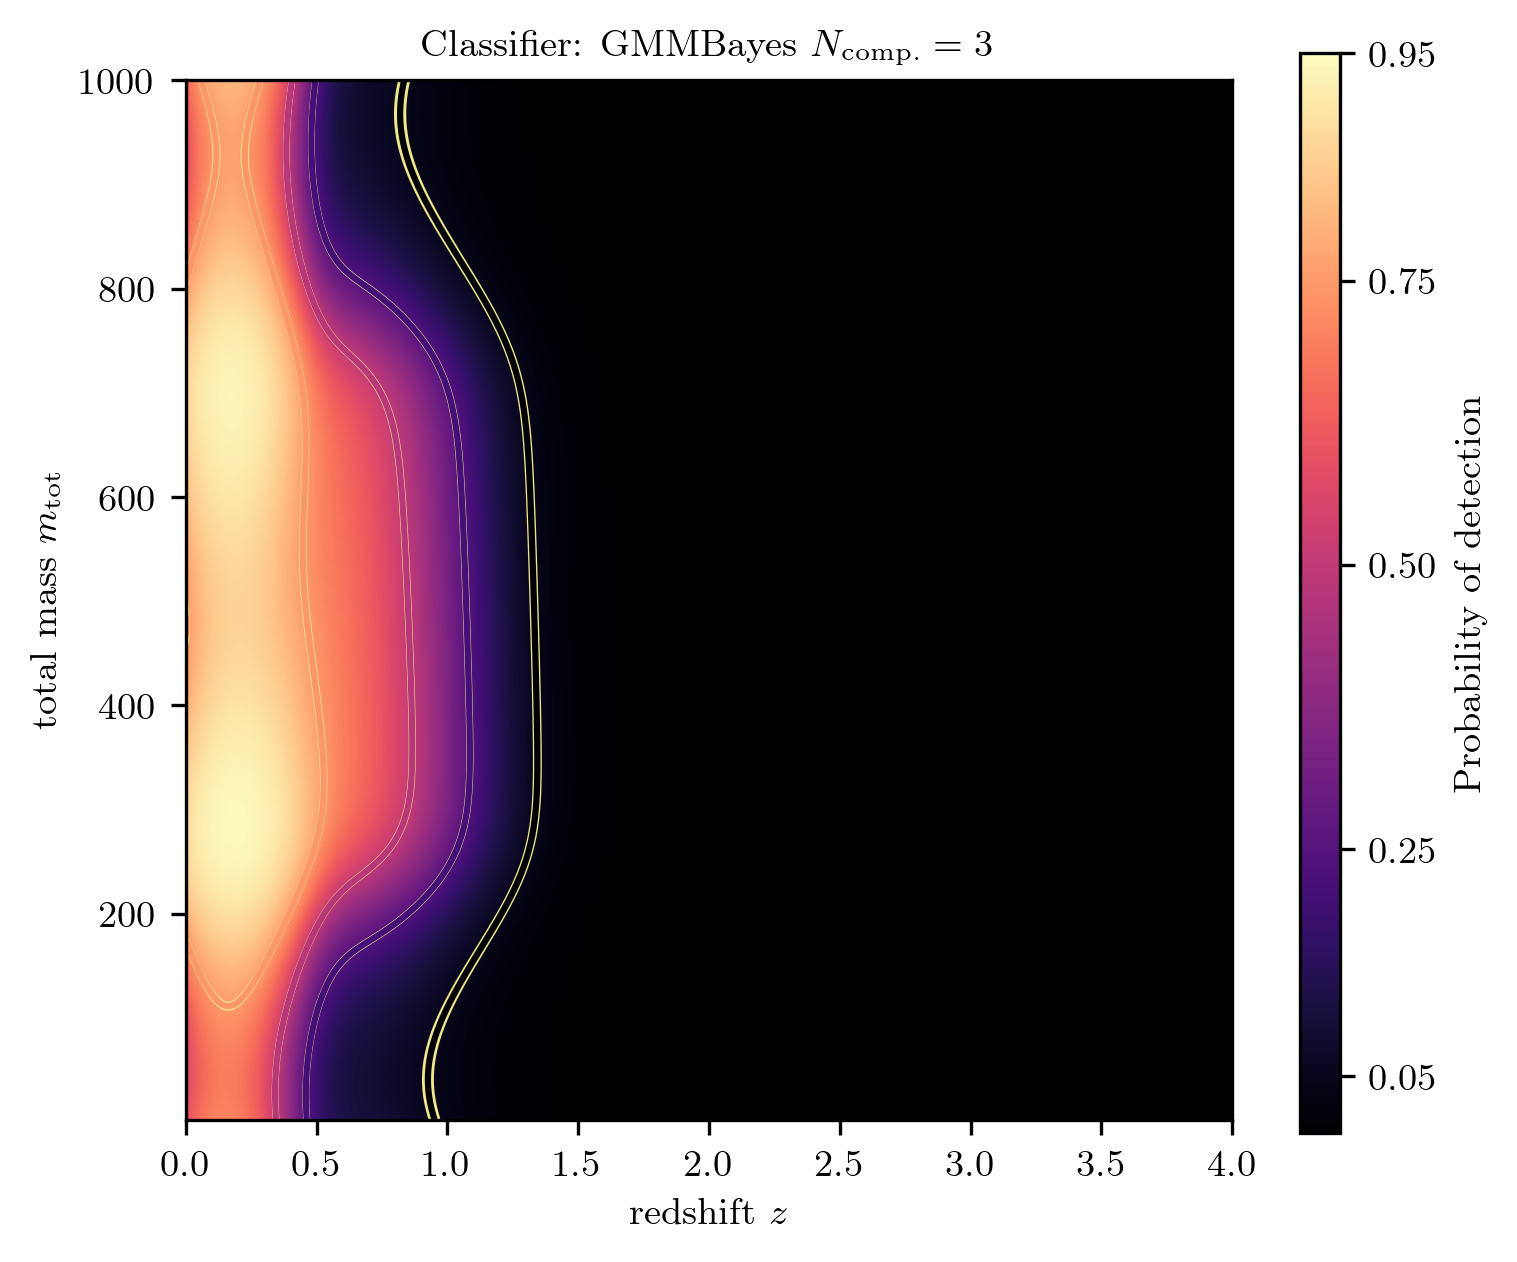

In [ ]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(4.5,4.5))

#-------------------------------------------------------------------------

x0, x1 = np.meshgrid(
    np.linspace(lims[0][0], lims[0][1], 500),
    np.linspace(lims[1][0], lims[1][1], 500)
)

yy_GMMBayes = classifiers_GMMBayes[2][0].predict_proba(np.c_[x0.ravel(), x1.ravel()])
yy_GMMBayes = yy_GMMBayes[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims[0][0], lims[0][1], 500)
xb = np.linspace(lims[1][0], lims[1][1], 500)
py = yy_GMMBayes
# ax.contour(xa, xb, py, contours+0.002, colors='khaki')
# ax.contour(xa, xb, py, contours-0.002, colors='khaki')
ax.contour(xa, xb, py, contours, colors='khaki', linewidths=1.3)
ax.contour(xa, xb, py, contours, cmap=cmap, linewidths=1.2)
# im = ax.imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[0]+lims[1])
im = ax.imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[1])
cmapax = fig.add_axes([0.95, 0.1, 0.03, 0.8])
# cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, spacing='proportional', ticks=cmap_ticks, boundaries=cmap_bounds, format='%.2f') # %.1f
cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, ticks=cmap_ticks, format='%.2f')
cmapax.set_ylabel('Probability of detection')


#-------------------------------------------------------------------------
# plot also the data

ax.set_xlim(lims[0])
ax.set_ylim(lims[1])
ax.set_xlabel(axlabels[0])
ax.set_ylabel(axlabels[1])
# ax.scatter(x[index_det_n,0] , x[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax.scatter(x[index_det_y,0] , x[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax.set_title('Classifier: GMMBayes ' + r'$N_{\rm comp.} = 3$', fontsize=9)

if False:
    fig.savefig('./L20_images/L20_classifier_GMMBayes_Ncomps=3_Nfeats=2.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_GMMBayes_Ncomps=3_Nfeats=2.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

# Decision Tree classifier (Cross Validation for depth)

In [19]:
DT_clf = DecisionTreeClassifier()
depth_range = np.arange(1,14)

grid = GridSearchCV(DT_clf, param_grid={'max_depth': depth_range}, cv=5, verbose=3)
grid.fit(x, y)

best_depth = grid.best_params_['max_depth']
print("best parameter choice for max_depth:", best_depth)

Fitting 5 folds for each of 13 candidates, totalling 65 fits
[CV 1/5] END .......................max_depth=1;, score=0.936 total time=  16.4s
[CV 2/5] END .......................max_depth=1;, score=0.936 total time=  16.5s
[CV 3/5] END .......................max_depth=1;, score=0.936 total time=  16.3s
[CV 4/5] END .......................max_depth=1;, score=0.936 total time=  16.3s
[CV 5/5] END .......................max_depth=1;, score=0.936 total time=  16.4s
[CV 1/5] END .......................max_depth=2;, score=0.936 total time=  32.3s
[CV 2/5] END .......................max_depth=2;, score=0.936 total time=  30.3s
[CV 3/5] END .......................max_depth=2;, score=0.936 total time=  29.7s
[CV 4/5] END .......................max_depth=2;, score=0.936 total time=  32.2s
[CV 5/5] END .......................max_depth=2;, score=0.936 total time=  32.4s
[CV 1/5] END .......................max_depth=3;, score=0.941 total time=  44.8s
[CV 2/5] END .......................max_depth=3;

In [20]:
DT2d_clf = DecisionTreeClassifier(max_depth=best_depth)
criteria = ['gini', 'entropy']

grid2d = GridSearchCV(DT2d_clf, param_grid={'criterion': criteria, 'max_depth': [10,12]}, cv=5, verbose=3)
grid2d.fit(x, y)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV 1/5] END ......criterion=gini, max_depth=10;, score=0.953 total time= 3.1min
[CV 2/5] END ......criterion=gini, max_depth=10;, score=0.953 total time= 2.8min
[CV 3/5] END ......criterion=gini, max_depth=10;, score=0.953 total time= 2.8min
[CV 4/5] END ......criterion=gini, max_depth=10;, score=0.953 total time= 3.1min
[CV 5/5] END ......criterion=gini, max_depth=10;, score=0.953 total time= 3.1min
[CV 1/5] END ......criterion=gini, max_depth=12;, score=0.953 total time= 3.3min
[CV 2/5] END ......criterion=gini, max_depth=12;, score=0.953 total time= 3.7min
[CV 3/5] END ......criterion=gini, max_depth=12;, score=0.953 total time= 3.3min
[CV 4/5] END ......criterion=gini, max_depth=12;, score=0.953 total time= 3.6min
[CV 5/5] END ......criterion=gini, max_depth=12;, score=0.953 total time= 2.9min
[CV 1/5] END ...criterion=entropy, max_depth=10;, score=0.952 total time= 2.6min
[CV 2/5] END ...criterion=entropy, max_depth=10;,

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(max_depth=np.int64(12)),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [10, 12]},
             verbose=3)

In [21]:
best_criterion_2d = grid2d.best_params_['criterion']
print("best parameter choice:", best_criterion_2d)
best_depth_2d = grid2d.best_params_['max_depth']
print("best parameter choice:", best_depth_2d)

best parameter choice: gini
best parameter choice: 12


In [22]:
#-------------------------------------------------------------------------
# Define the Decision Tree classifier
#-------------------------------------------------------------------------

@pickle_results('../../L20_DTree.pkl')
def compute_DTree(N_features, depth, crit, x_train, y_train, x_test, y_test):

    clf_           = []
    y_pred_        = []
    completeness_  = []
    contamination_ = []
    accuracy_      = []
    roc_fpr_       = []
    roc_tpr_       = []
    roc_auc_       = []

    for f_max in N_features:

        clf = DecisionTreeClassifier(max_depth=depth, criterion=crit)
        clf_.append(clf)

        clf.fit(x_train[:, :f_max], y_train)

        y_prob = clf.predict_proba(x_test[:, :f_max])
        y_pred = clf.predict(x_test[:, :f_max])
        y_pred_.append(y_pred)

        completeness, contamination = completeness_contamination(y_pred, y_test)
        accuracy = accuracy_score(y_test, y_pred)
        completeness_.append(completeness)
        contamination_.append(contamination)
        accuracy_.append(accuracy)
        
        roc_fpr , roc_tpr, roc_tresh = roc_curve(y_test, y_prob[:,1])
        roc_auc = roc_auc_score(y_test, y_prob[:,1])
        roc_fpr_.append(roc_fpr)
        roc_tpr_.append(roc_tpr)
        roc_auc_.append(roc_auc)

        print('DecisionTree depth {:d} features {:d} done!'.format(depth,f_max))
        
    return clf_, completeness_, contamination_, accuracy_, roc_fpr_, roc_tpr_, roc_auc_

#-------------------------------------------------------------------------

In [23]:
#-------------------------------------------------------------------------
# Run the Decision Tree classifier
#-------------------------------------------------------------------------

x_train_DTree = x_train 
x_test_DTree  = x_test
y_train_DTree = y_train 
y_test_DTree  = y_test

N_features_DTree = [2,3]

classifiers_DTree,  \
completeness_DTree, \
contamination_DTree,\
accuracy_DTree,     \
roc_fpr_DTree,      \
roc_tpr_DTree,      \
roc_auc_DTree,      \
= compute_DTree(
    N_features_DTree, 
    best_depth_2d,
    best_criterion_2d,
    x_train_DTree, 
    y_train_DTree, 
    x_test_DTree, 
    y_test_DTree
)

#-------------------------------------------------------------------------

@pickle_results: computing results and saving to '../../L20_DTree.pkl'
DecisionTree depth 12 features 2 done!
DecisionTree depth 12 features 3 done!


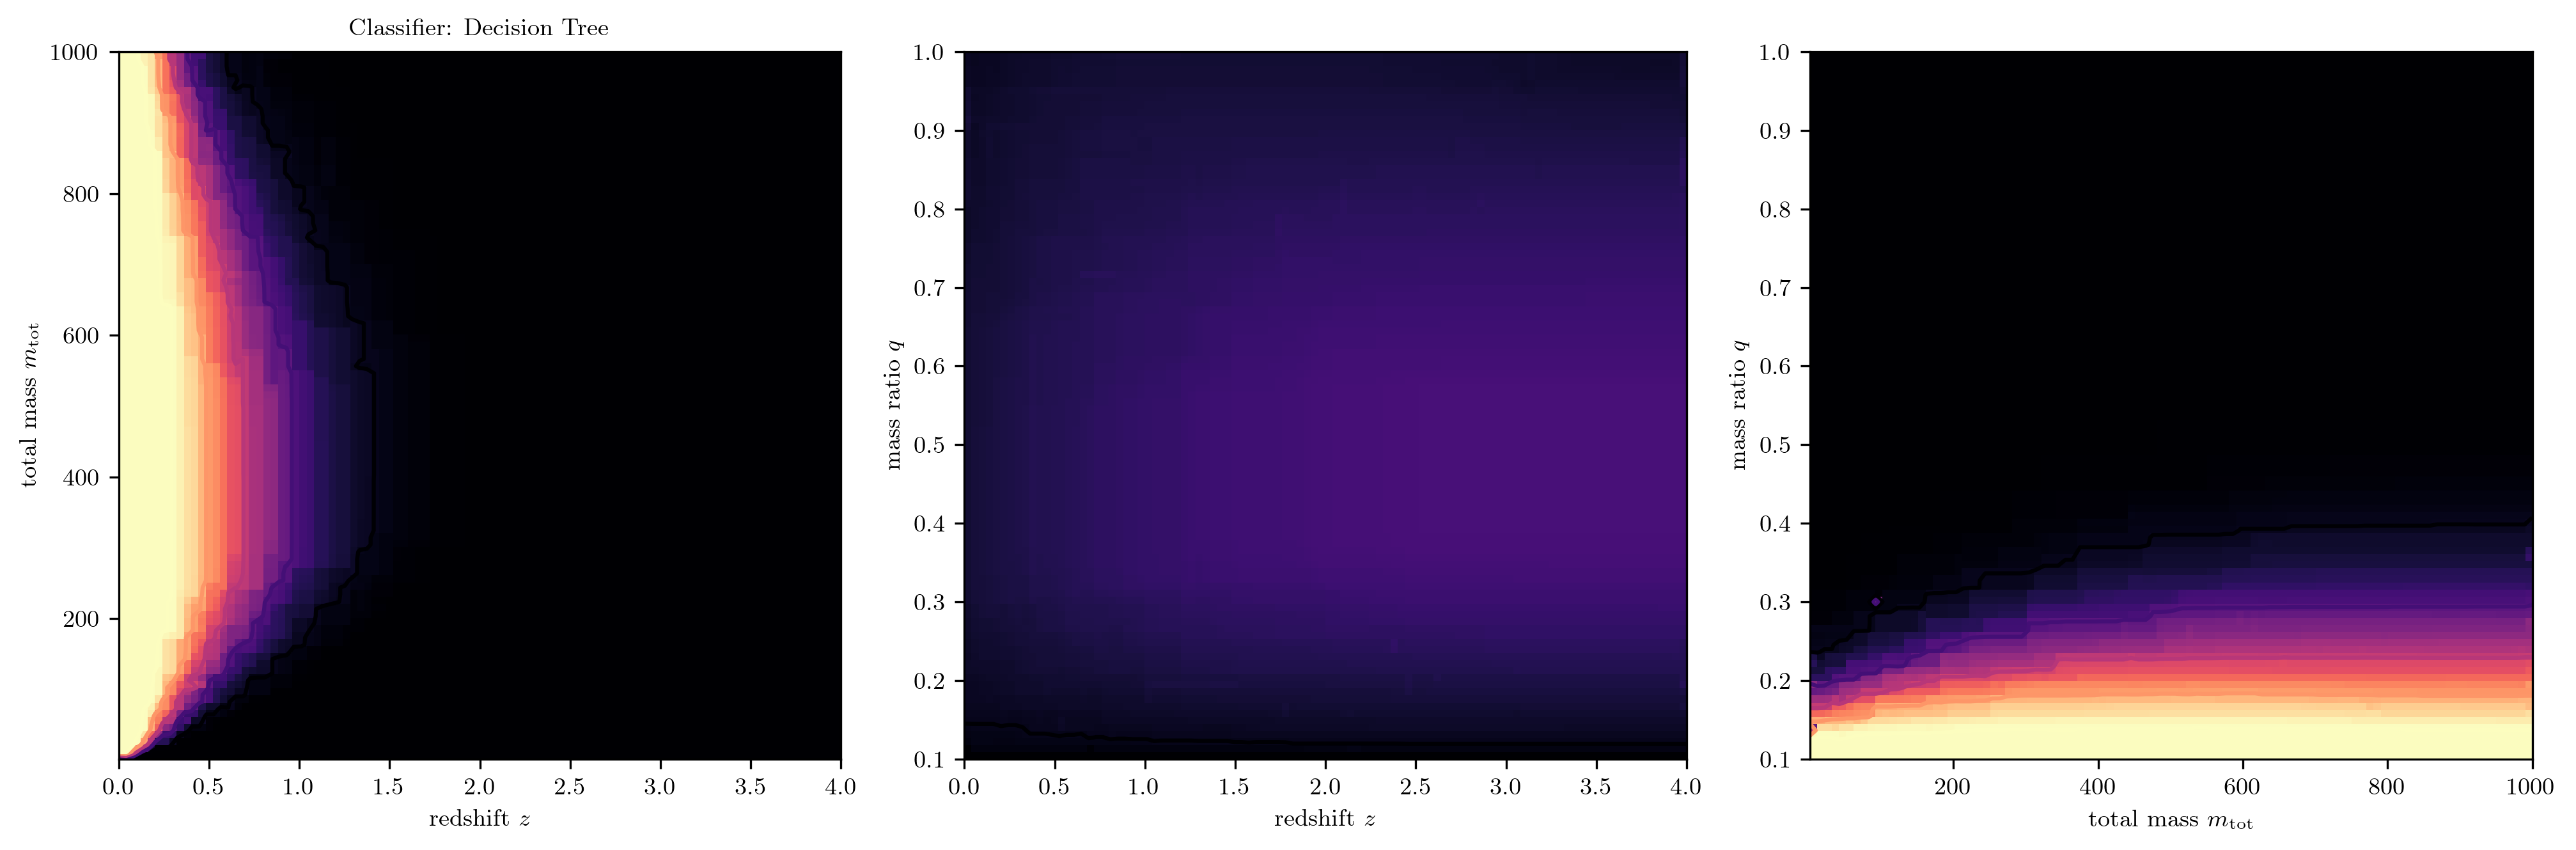

In [ ]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(4.5*3,4.5))

#-------------------------------------------------------------------------

x0, x1, x2 = np.meshgrid(
    np.linspace(lims[0][0], lims[0][1], 100),
    np.linspace(lims[1][0], lims[1][1], 100),
    np.linspace(lims[2][0], lims[2][1], 100)
)

yy_DTree = classifiers_DTree[-1].predict_proba(np.c_[x0.ravel(), x1.ravel(), x2.ravel()])
yy_DTree = yy_DTree[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims[0][0], lims[0][1], 100)
xb = np.linspace(lims[1][0], lims[1][1], 100)
py = yy_DTree.sum(axis=2)/100
ax[0].contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax[0].contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
# im = ax[0].imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[0]+lims[1])
im = ax[0].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[1])


# x0 = z ; x2 = q
xa = np.linspace(lims[0][0], lims[0][1], 100)
xb = np.linspace(lims[2][0], lims[2][1], 100)
py = yy_DTree.sum(axis=1)/100
ax[1].contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax[1].contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
im = ax[1].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[2])

# x1 = m_tot ; x2 = q
xa = np.linspace(lims[1][0], lims[1][1], 100)
xb = np.linspace(lims[2][0], lims[2][1], 100)
py = yy_DTree.sum(axis=0)/100
ax[2].contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax[2].contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
im = ax[2].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[1]+lims[2])

#-------------------------------------------------------------------------
# plot also the data


ax[0].set_xlim(lims[0])
ax[0].set_ylim(lims[1])
ax[0].set_xlabel(axlabels[0])
ax[0].set_ylabel(axlabels[1])
# ax[0].scatter(x[index_det_n,0] , x[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[0].scatter(x[index_det_y,0] , x[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax[1].set_xlim(lims[0])
ax[1].set_ylim(lims[2])
ax[1].set_xlabel(axlabels[0])
ax[1].set_ylabel(axlabels[2])
# ax[1].scatter(x[index_det_n,0] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[1].scatter(x[index_det_y,0] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

ax[2].set_xlim(lims[1])
ax[2].set_ylim(lims[2])
ax[2].set_xlabel(axlabels[1])
ax[2].set_ylabel(axlabels[2])
# ax[2].scatter(x[index_det_n,1] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[2].scatter(x[index_det_y,1] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

ax[0].set_title('Classifier: Decision Tree ', fontsize=9)

fig.tight_layout()

if False:
    fig.savefig('./L20_images/L20_classifier_DTree_Depth=12_Nfeats=3.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_DTree_Depth=12_Nfeats=3.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

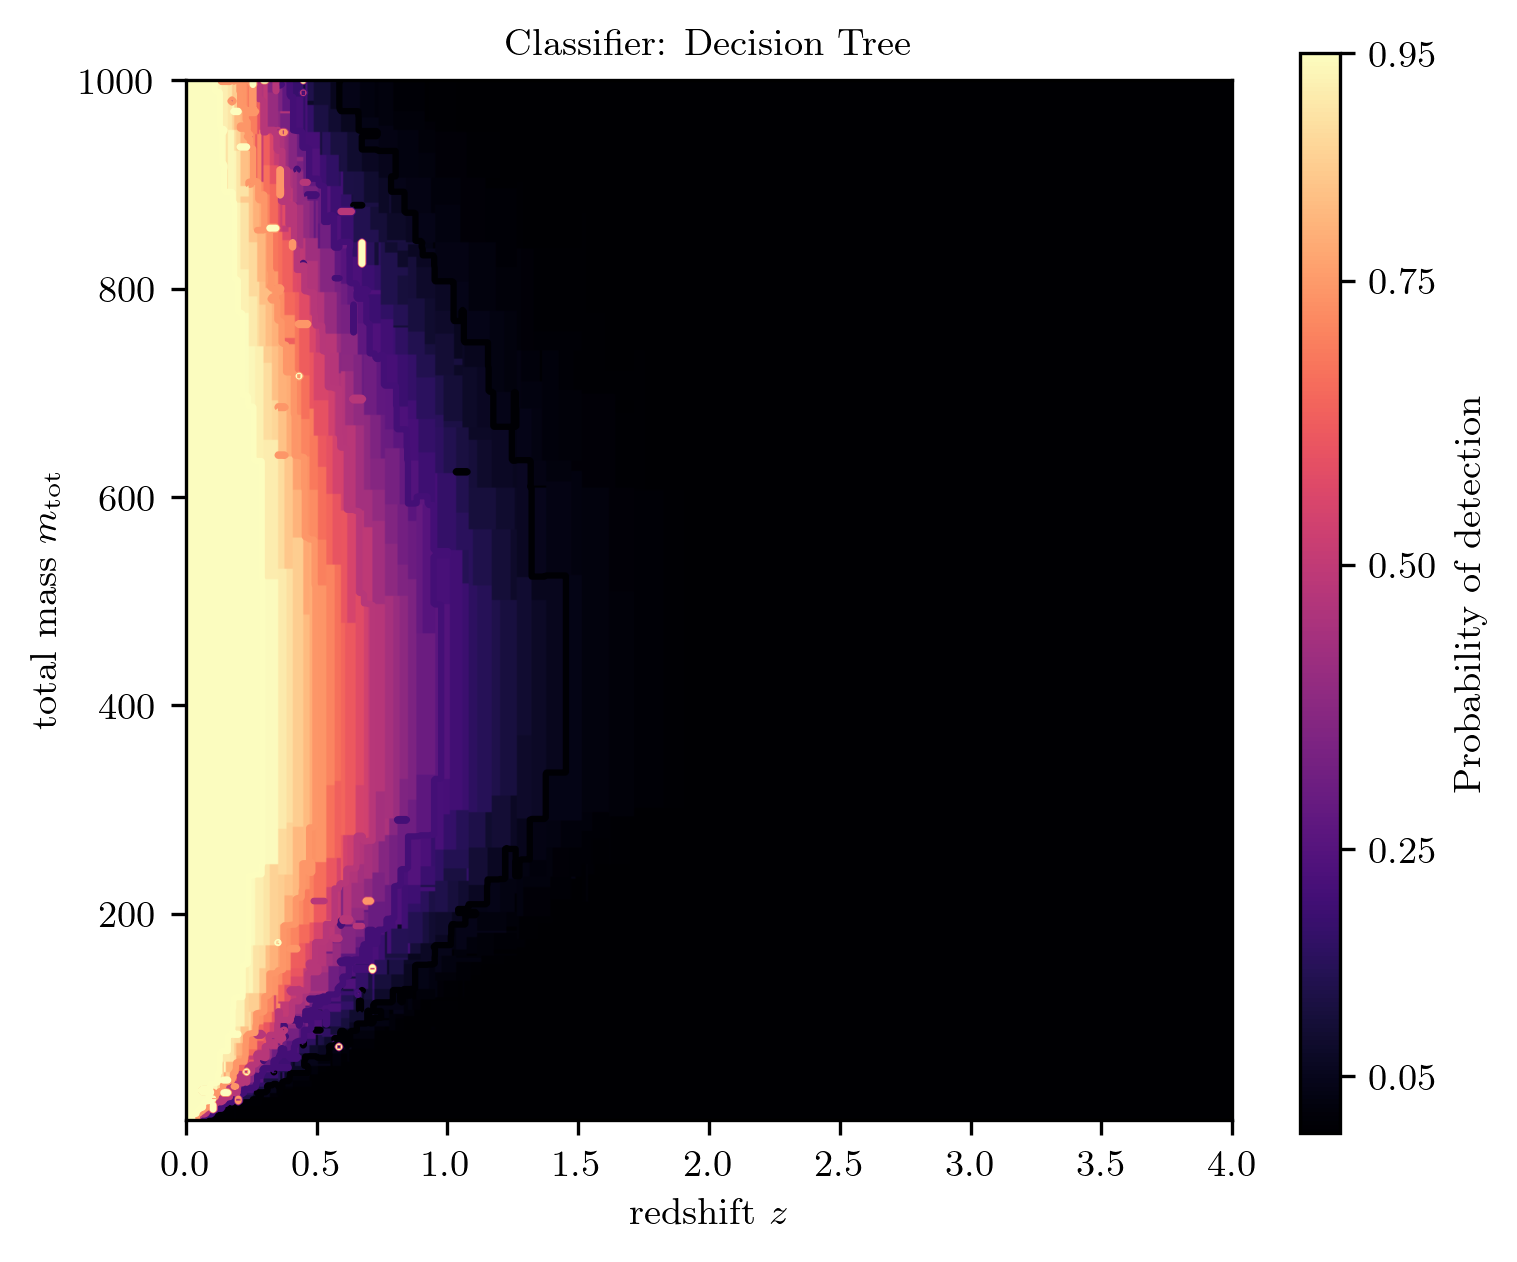

In [25]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(4.5,4.5))

#-------------------------------------------------------------------------

x0, x1 = np.meshgrid(
    np.linspace(lims[0][0], lims[0][1], 500),
    np.linspace(lims[1][0], lims[1][1], 500)
)

yy_DTree = classifiers_DTree[0].predict_proba(np.c_[x0.ravel(), x1.ravel()])
yy_DTree = yy_DTree[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims[0][0], lims[0][1], 500)
xb = np.linspace(lims[1][0], lims[1][1], 500)
py = yy_DTree
ax.contour(xa, xb, py, contours, cmap=cmap)
# im = ax.imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[0]+lims[1])
im = ax.imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[1])
cmapax = fig.add_axes([0.95, 0.1, 0.03, 0.8])
# cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, spacing='proportional', ticks=cmap_ticks, boundaries=cmap_bounds, format='%.2f') # %.1f
cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, ticks=cmap_ticks, format='%.2f')
cmapax.set_ylabel('Probability of detection')


#-------------------------------------------------------------------------
# plot also the data

ax.set_xlim(lims[0])
ax.set_ylim(lims[1])
ax.set_xlabel(axlabels[0])
ax.set_ylabel(axlabels[1])
# ax.scatter(x[index_det_n,0] , x[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax.scatter(x[index_det_y,0] , x[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax.set_title('Classifier: Decision Tree ', fontsize=9)

if False:
    fig.savefig('./L20_images/L20_classifier_DTree_Depth=12_Nfeats=2.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_DTree_Depth=12_Nfeats=2.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

# Random Forest classifier - accuracy $\sim 95\%$

In [26]:
#-------------------------------------------------------------------------
# Define the Random Forest classifier
#-------------------------------------------------------------------------

def compute_RForest_(N_features, depth, crit, x_train, y_train, x_test, y_test):

    clf_           = []
    y_pred_        = []
    completeness_  = []
    contamination_ = []
    accuracy_      = []
    roc_fpr_       = []
    roc_tpr_       = []
    roc_auc_       = []

    for f_max in N_features:

        clf = RandomForestClassifier(
            n_estimators=100, 
            max_depth=depth, 
            criterion=crit,
            n_jobs=-1,
            verbose=3
        )
        clf_.append(clf)

        clf.fit(x_train[:, :f_max], y_train)

        y_prob = clf.predict_proba(x_test[:, :f_max])
        y_pred = clf.predict(x_test[:, :f_max])
        y_pred_.append(y_pred)

        completeness, contamination = completeness_contamination(y_pred, y_test)
        accuracy = accuracy_score(y_test, y_pred)
        completeness_.append(completeness)
        contamination_.append(contamination)
        accuracy_.append(accuracy)
        
        roc_fpr , roc_tpr, roc_tresh = roc_curve(y_test, y_prob[:,1])
        roc_auc = roc_auc_score(y_test, y_prob[:,1])
        roc_fpr_.append(roc_fpr)
        roc_tpr_.append(roc_tpr)
        roc_auc_.append(roc_auc)

        print('RandomForest depth {:d} features {:d} done!'.format(depth,f_max))
        
    return clf_, completeness_, contamination_, accuracy_, roc_fpr_, roc_tpr_, roc_auc_

#-------------------------------------------------------------------------

@pickle_results('../../L20_RandomForest.pkl')
def compute_RForest(N_features, depth, crit, x_train, y_train, x_test, y_test):
    return compute_RForest_(N_features, depth, crit, x_train, y_train, x_test, y_test)

#-------------------------------------------------------------------------

@pickle_results('../../L20_RandomForest_PCA.pkl')
def compute_RForest_PCA(N_features, depth, crit, x_train, y_train, x_test, y_test):
    return compute_RForest_(N_features, depth, crit, x_train, y_train, x_test, y_test)

#-------------------------------------------------------------------------

@pickle_results('../../L20_RandomForest_ICA.pkl')
def compute_RForest_ICA(N_features, depth, crit, x_train, y_train, x_test, y_test):
    return compute_RForest_(N_features, depth, crit, x_train, y_train, x_test, y_test)

#-------------------------------------------------------------------------


In [27]:
#-------------------------------------------------------------------------
# Run the Random Forest classifier
#-------------------------------------------------------------------------

x_train_RForest = x_train 
x_test_RForest  = x_test
y_train_RForest = y_train 
y_test_RForest  = y_test

N_features_RForest = [2,3]

classifiers_RForest,  \
completeness_RForest, \
contamination_RForest,\
accuracy_RForest,     \
roc_fpr_RForest,      \
roc_tpr_RForest,      \
roc_auc_RForest,      \
= compute_RForest(
    N_features_RForest, 
    best_depth_2d,
    best_criterion_2d,
    x_train_RForest, 
    y_train_RForest, 
    x_test_RForest, 
    y_test_RForest
)

#-------------------------------------------------------------------------

@pickle_results: computing results and saving to '../../L20_RandomForest.pkl'


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100building tree 2 of 100
building tree 3 of 100
building tree 6 of 100
building tree 5 of 100
building tree 4 of 100
building tree 7 of 100
building tree 8 of 100

building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100


[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  2.6min


building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66

...

building tree 2 of 100
building tree 6 of 100
building tree 7 of 100
building tree 5 of 100
building tree 8 of 100
building tree 4 of 100
building tree 3 of 100
building tree 1 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100


[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  2.8min


building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100building tree 44 of 100

building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100building tree 52 of 100

building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 15.3min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    4.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   26.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    4.5s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   26.3s finished


RandomForest depth 12 features 3 done!


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.7s finished


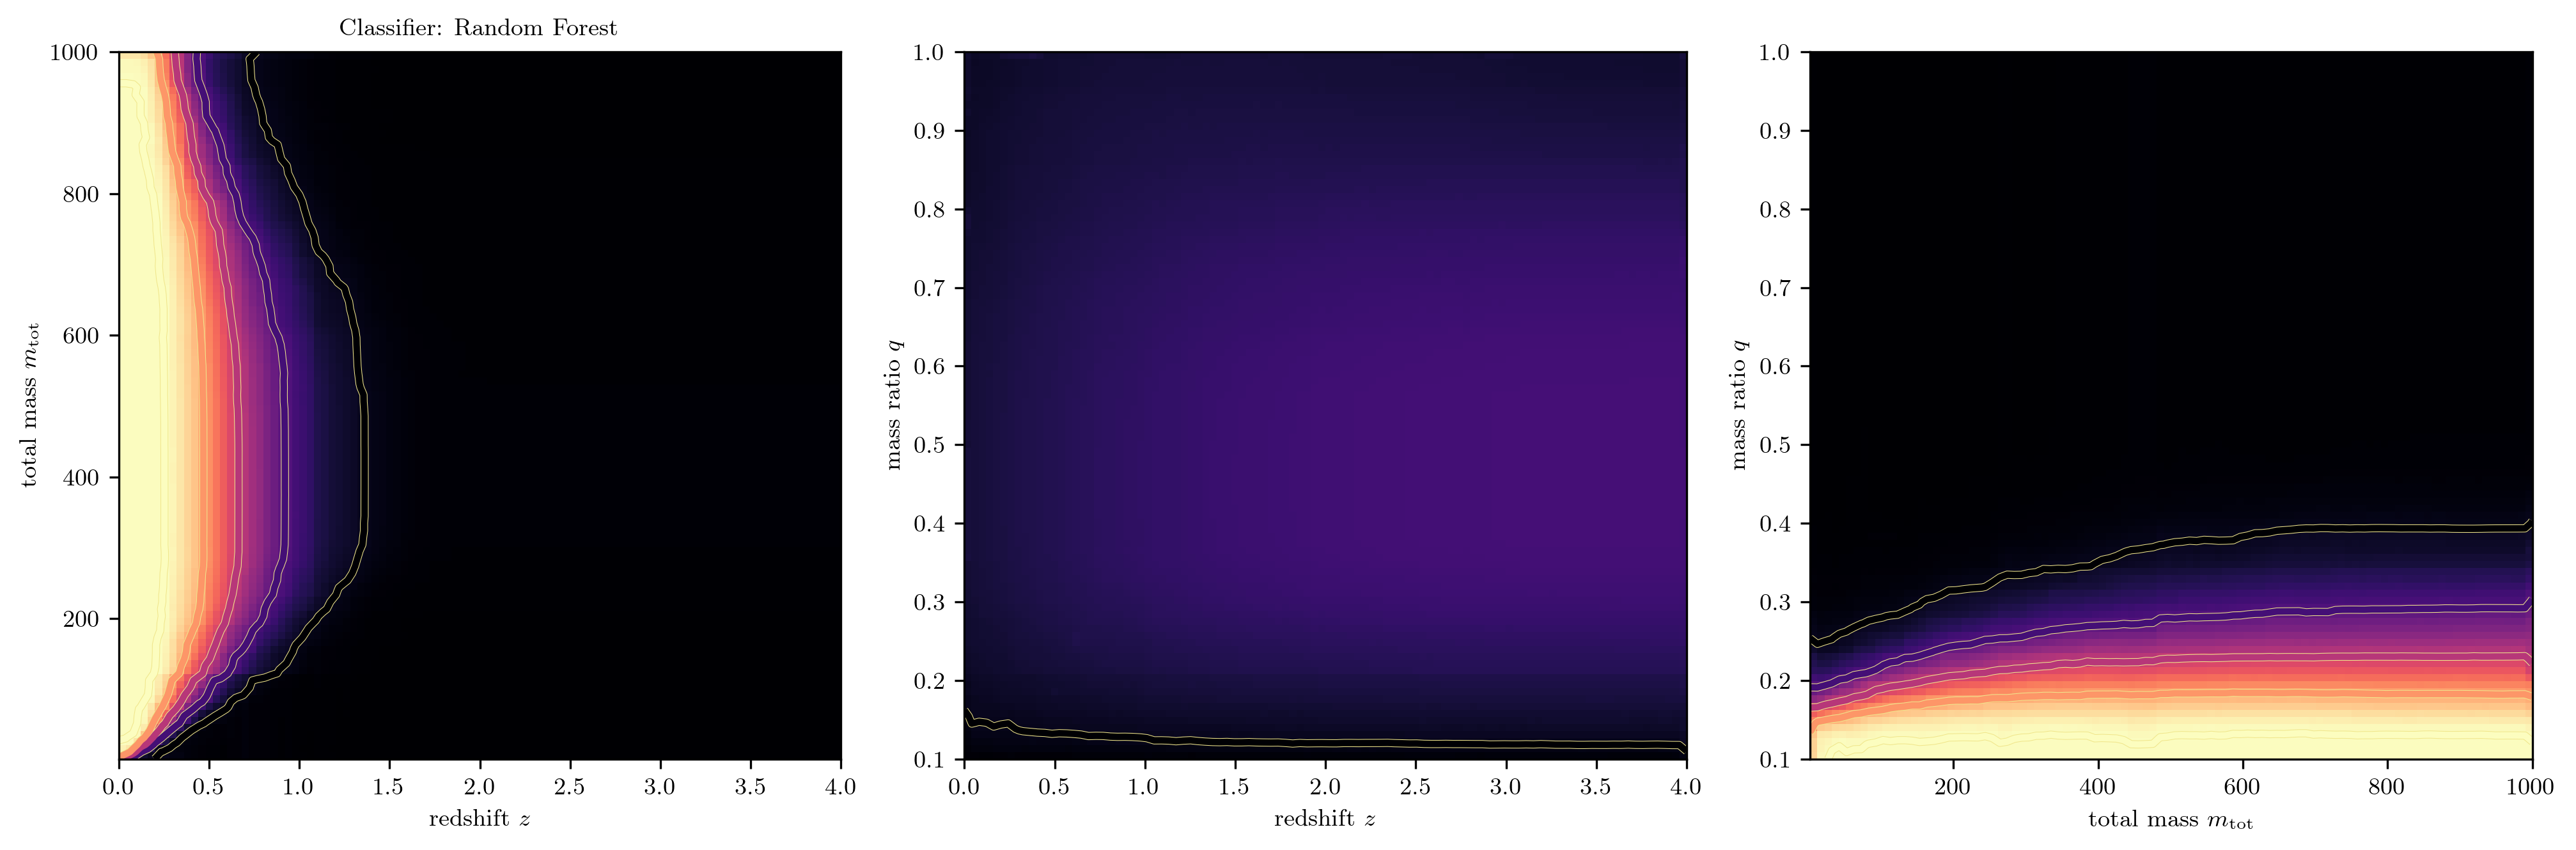

In [37]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(1,3,figsize=(4.5*3,4.5))

#-------------------------------------------------------------------------

x0, x1, x2 = np.meshgrid(
    np.linspace(lims[0][0], lims[0][1], 100),
    np.linspace(lims[1][0], lims[1][1], 100),
    np.linspace(lims[2][0], lims[2][1], 100)
)

yy_RForest = classifiers_RForest[-1].predict_proba(np.c_[x0.ravel(), x1.ravel(), x2.ravel()])
yy_RForest = yy_RForest[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims[0][0], lims[0][1], 100)
xb = np.linspace(lims[1][0], lims[1][1], 100)
py = yy_RForest.sum(axis=2)/100
ax[0].contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax[0].contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
# im = ax[0].imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[0]+lims[1])
im = ax[0].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[1])

# x0 = z ; x2 = q
xa = np.linspace(lims[0][0], lims[0][1], 100)
xb = np.linspace(lims[2][0], lims[2][1], 100)
py = yy_RForest.sum(axis=1)/100
ax[1].contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax[1].contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
im = ax[1].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[2])

# x1 = m_tot ; x2 = q
xa = np.linspace(lims[1][0], lims[1][1], 100)
xb = np.linspace(lims[2][0], lims[2][1], 100)
py = yy_RForest.sum(axis=0)/100
ax[2].contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax[2].contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
im = ax[2].imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[1]+lims[2])

#-------------------------------------------------------------------------
# plot also the data

ax[0].set_xlim(lims[0])
ax[0].set_ylim(lims[1])
ax[0].set_xlabel(axlabels[0])
ax[0].set_ylabel(axlabels[1])
# ax[0].scatter(x[index_det_n,0] , x[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[0].scatter(x[index_det_y,0] , x[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax[1].set_xlim(lims[0])
ax[1].set_ylim(lims[2])
ax[1].set_xlabel(axlabels[0])
ax[1].set_ylabel(axlabels[2])
# ax[1].scatter(x[index_det_n,0] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[1].scatter(x[index_det_y,0] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

ax[2].set_xlim(lims[1])
ax[2].set_ylim(lims[2])
ax[2].set_xlabel(axlabels[1])
ax[2].set_ylabel(axlabels[2])
# ax[2].scatter(x[index_det_n,1] , x[index_det_n,2] , color='lightskyblue', s=0.1, alpha=0.05)
# ax[2].scatter(x[index_det_y,1] , x[index_det_y,2] , color='lightcoral', s=0.1, alpha=0.05)

ax[0].set_title('Classifier: Random Forest', fontsize=9)

fig.tight_layout()

if False:
    fig.savefig('./L20_images/L20_classifier_RForest_Depth=12_Nfeats=3.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_RForest_Depth=12_Nfeats=3.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished


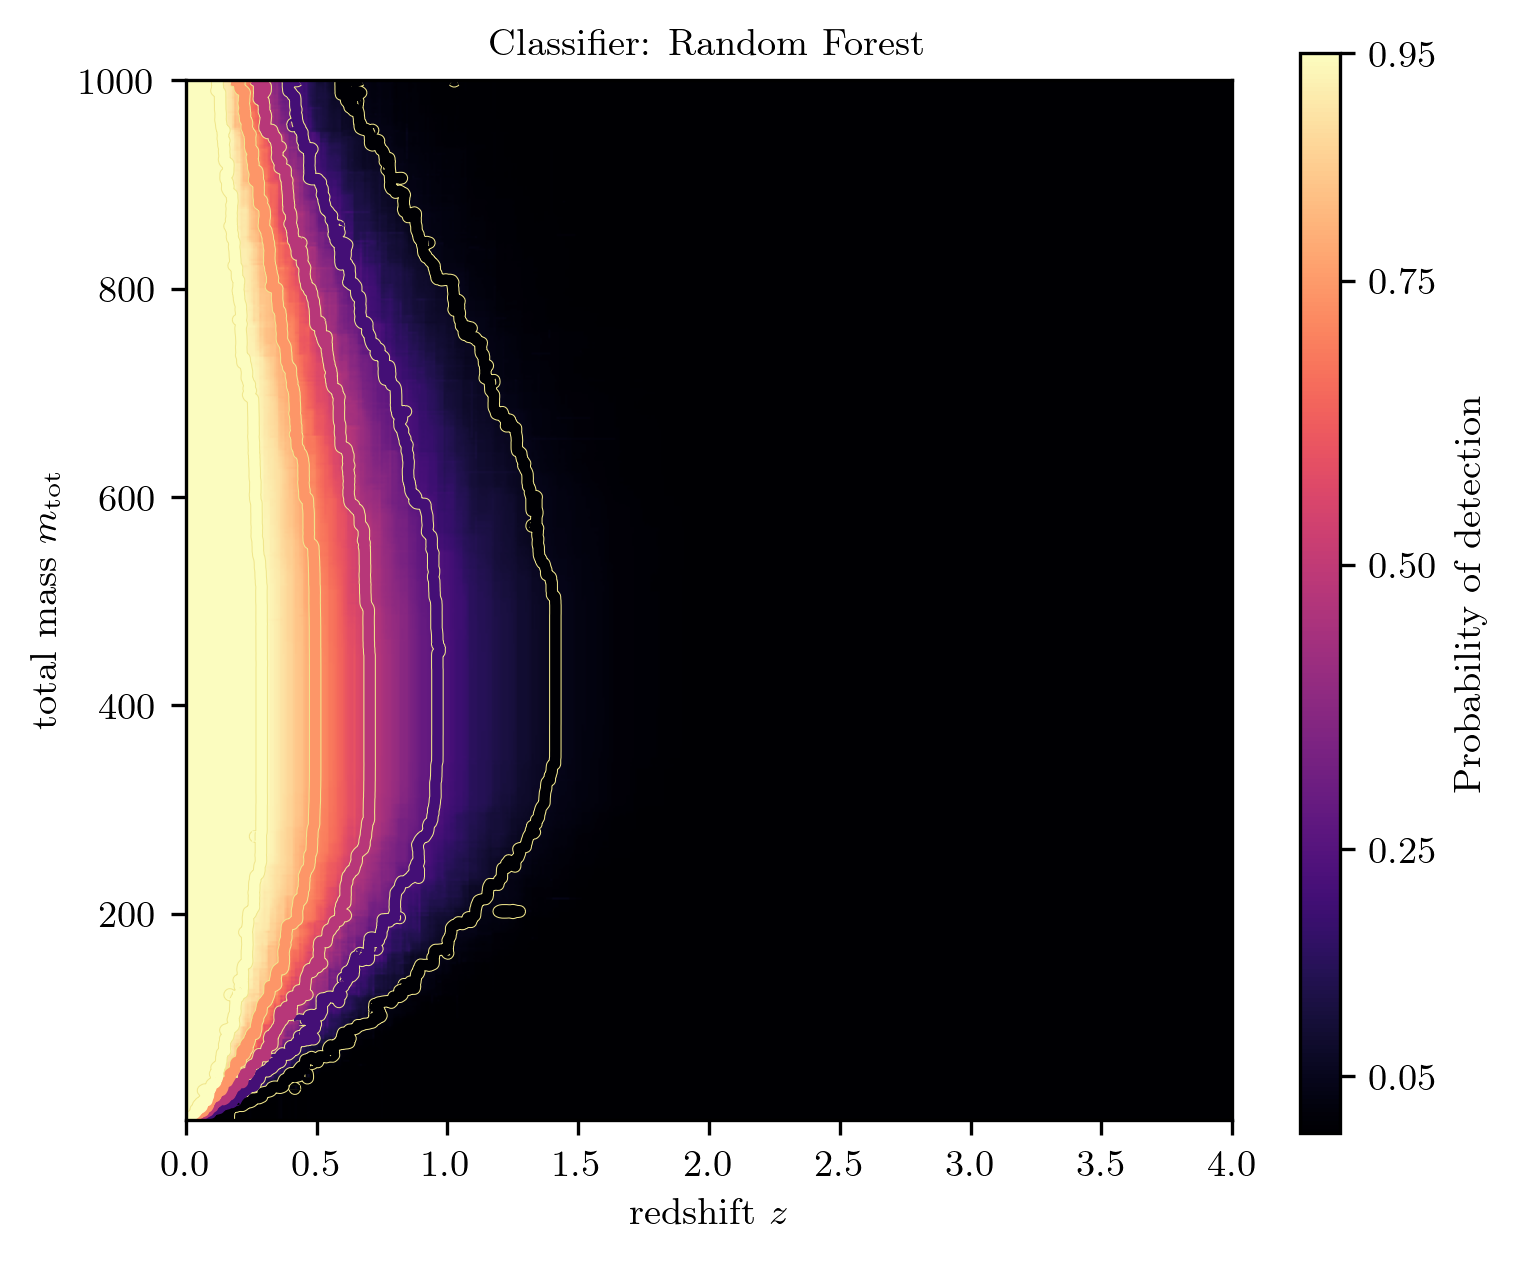

In [36]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(4.5,4.5))

#-------------------------------------------------------------------------

x0, x1 = np.meshgrid(
    np.linspace(lims[0][0], lims[0][1], 500),
    np.linspace(lims[1][0], lims[1][1], 500)
)

yy_RForest = classifiers_RForest[0].predict_proba(np.c_[x0.ravel(), x1.ravel()])
yy_RForest = yy_RForest[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims[0][0], lims[0][1], 500)
xb = np.linspace(lims[1][0], lims[1][1], 500)
py = yy_RForest
ax.contour(xa, xb, py, contours, colors='khaki', linewidths=3)
ax.contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
# im = ax.imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[0]+lims[1])
im = ax.imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims[0]+lims[1])
cmapax = fig.add_axes([0.95, 0.1, 0.03, 0.8])
# cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, spacing='proportional', ticks=cmap_ticks, boundaries=cmap_bounds, format='%.2f') # %.1f
cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, ticks=cmap_ticks, format='%.2f')
cmapax.set_ylabel('Probability of detection')

#-------------------------------------------------------------------------
# plot also the data

ax.set_xlim(lims[0])
ax.set_ylim(lims[1])
ax.set_xlabel(axlabels[0])
ax.set_ylabel(axlabels[1])
# ax.scatter(x[index_det_n,0] , x[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax.scatter(x[index_det_y,0] , x[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax.set_title('Classifier: Random Forest ', fontsize=9)

if False:
    fig.savefig('./L20_images/L20_classifier_RForest_Depth=12_Nfeats=2.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_RForest_Depth=12_Nfeats=2.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

# Dimensionality reduction

# PCA $\to$ RandomForest classifier - accuracy $\sim 95\%$

In [38]:
tsne   = TSNE(n_components=2, n_jobs=-1, init='pca', verbose=10)
isomap = Isomap(n_components=2, n_jobs=-1)
pca    = PCA(n_components=2)
ica    = FastICA(n_components=2)

In [39]:
x_pca    = pca.fit_transform(x)
x_ica    = ica.fit_transform(x)

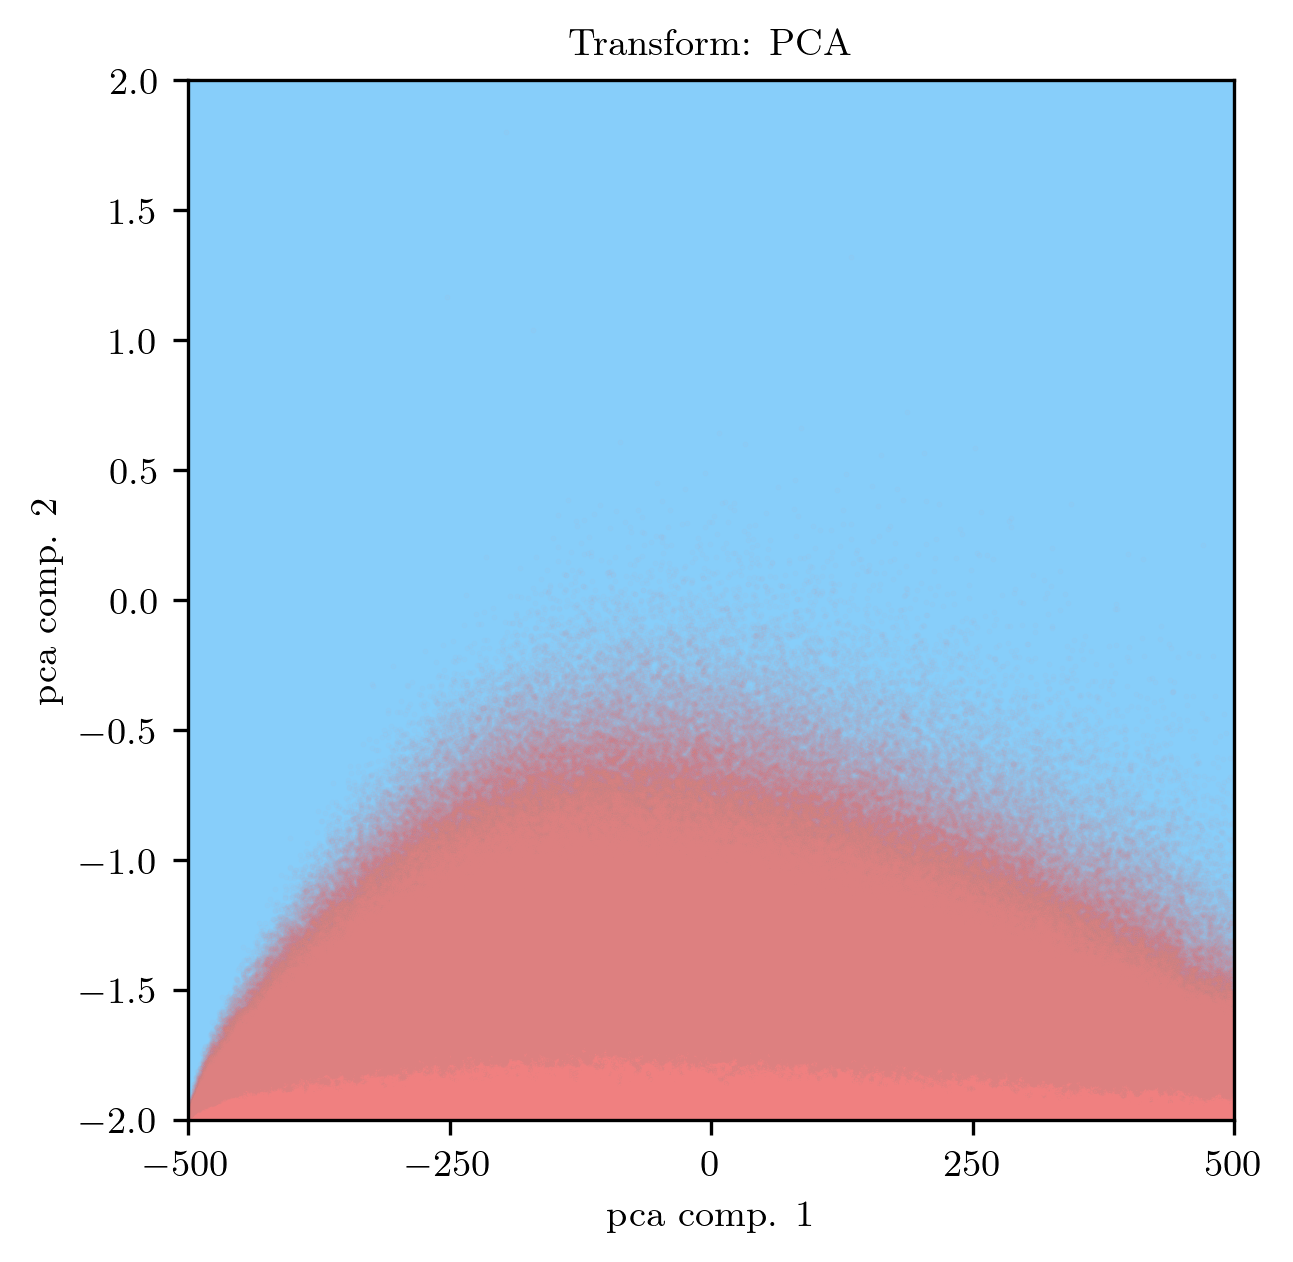

In [40]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(4.5,4.5))

#-------------------------------------------------------------------------
# plot also the data

lims_pca = [(-500,+500),(-2,+2)]
axlabels_pca = [r'pca comp. 1',r'pca comp. 2']

ax.set_xlim(lims_pca[0])
ax.set_ylim(lims_pca[1])
ax.set_xlabel(axlabels_pca[0])
ax.set_ylabel(axlabels_pca[1])
ax.xaxis.set_major_locator(plt.MultipleLocator(250))
ax.scatter(x_pca[index_det_n,0] , x_pca[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
ax.scatter(x_pca[index_det_y,0] , x_pca[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax.set_title('Transform: PCA ', fontsize=9)

if False:
    fig.savefig('./L20_images/L20_transform_PCA_Nfeats=2.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_transform_PCA_Nfeats=2.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

In [41]:
#-------------------------------------------------------------------------
# Run the Random Forest classifier
#-------------------------------------------------------------------------

x_train_PCA = pca.transform(x_train)
x_test_PCA  = pca.transform(x_test)
y_train_PCA = y_train
y_test_PCA  = y_test

N_features_PCA = [2]

classifiers_PCA,  \
completeness_PCA, \
contamination_PCA,\
accuracy_PCA,     \
roc_fpr_PCA,      \
roc_tpr_PCA,      \
roc_auc_PCA,      \
= compute_RForest_PCA(
    N_features_PCA, 
    best_depth_2d,
    best_criterion_2d,
    x_train_PCA, 
    y_train_PCA, 
    x_test_PCA, 
    y_test_PCA
)

#-------------------------------------------------------------------------

@pickle_results: using precomputed results from '../../L20_RandomForest_PCA.pkl'


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished


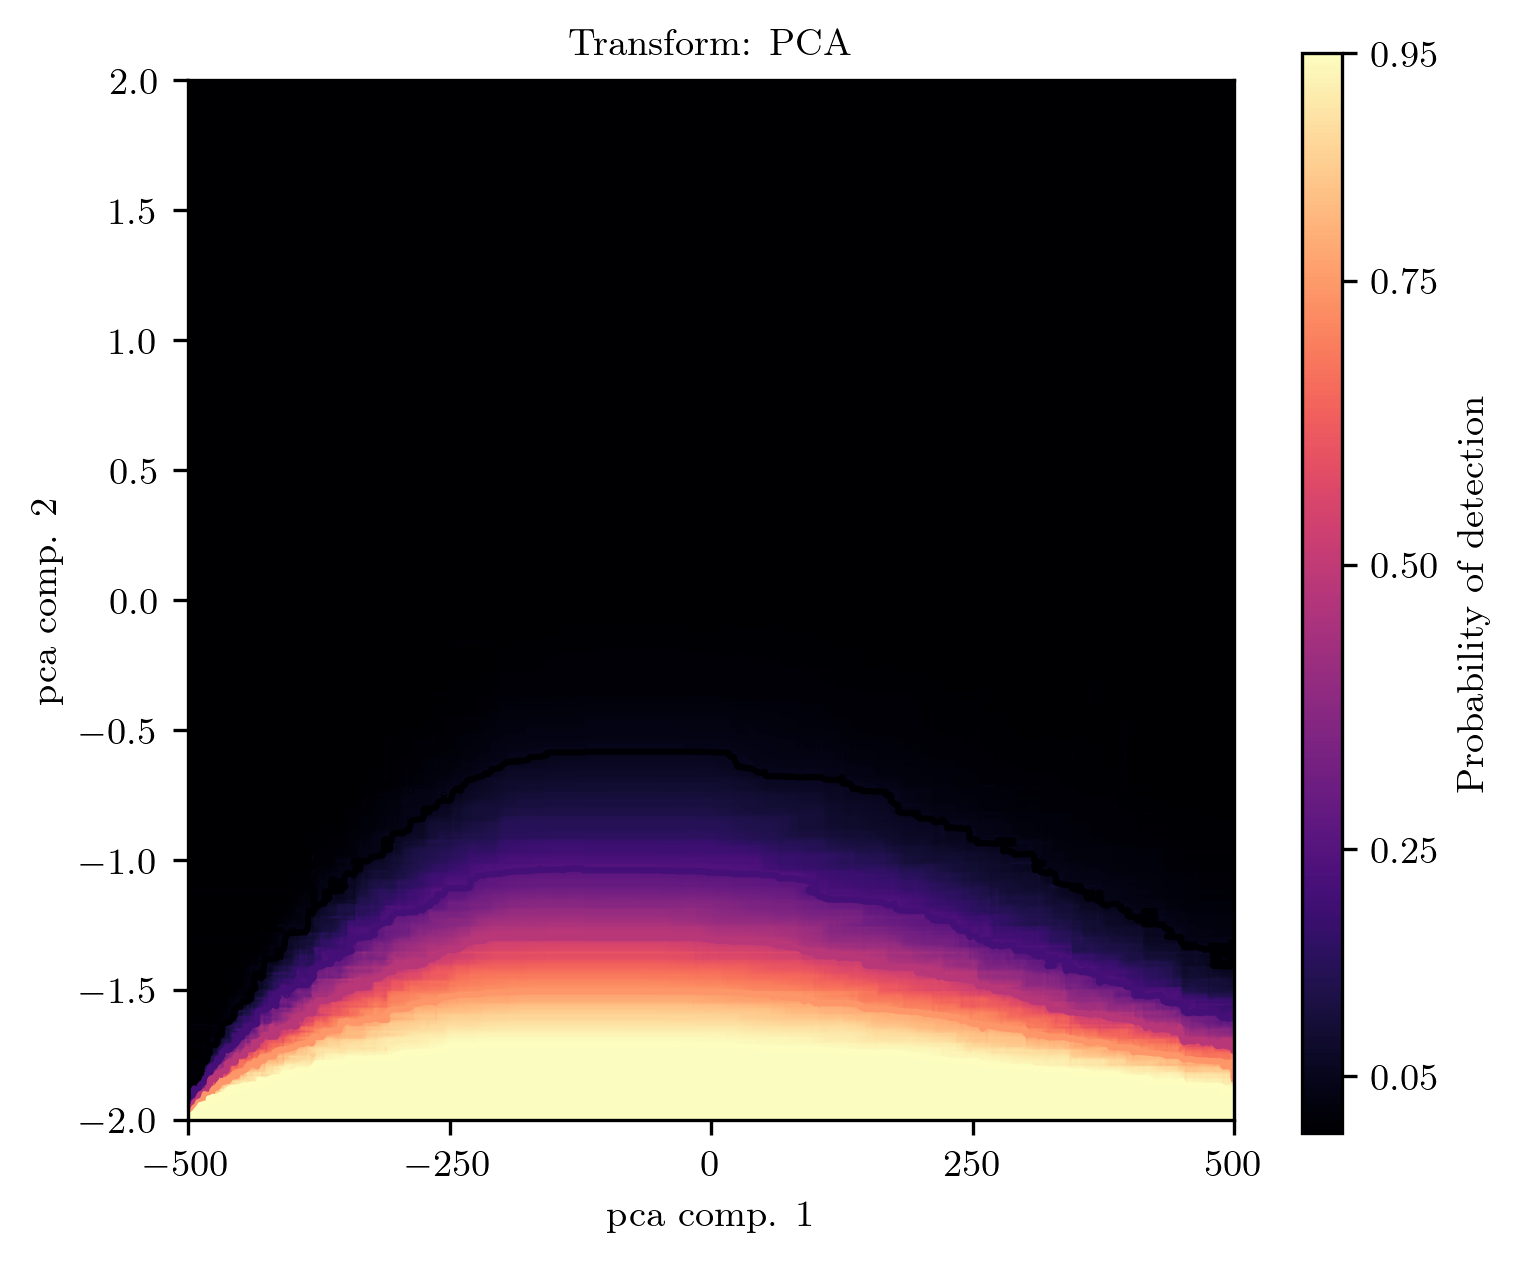

In [ ]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(4.5,4.5))

#-------------------------------------------------------------------------

x0, x1 = np.meshgrid(
    np.linspace(lims_pca[0][0], lims_pca[0][1], 500),
    np.linspace(lims_pca[1][0], lims_pca[1][1], 500)
)

yy_pca = classifiers_PCA[0].predict_proba(np.c_[x0.ravel(), x1.ravel()])
yy_pca = yy_pca[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims_pca[0][0], lims_pca[0][1], 500)
xb = np.linspace(lims_pca[1][0], lims_pca[1][1], 500)
py = yy_pca
# ax.contour(xa, xb, py, contours+0.002, colors='khaki')
# ax.contour(xa, xb, py, contours-0.002, colors='khaki')
ax.contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax.contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
im = ax.imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims_pca[0]+lims_pca[1])
cmapax = fig.add_axes([0.95, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, ticks=cmap_ticks, format='%.2f')
cmapax.set_ylabel('Probability of detection')

#-------------------------------------------------------------------------
# plot also the data

ax.set_xlim(lims_pca[0])
ax.set_ylim(lims_pca[1])
ax.set_xlabel(axlabels_pca[0])
ax.set_ylabel(axlabels_pca[1])
ax.xaxis.set_major_locator(plt.MultipleLocator(250))
# ax.scatter(x_pca[index_det_n,0] , x_pca[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax.scatter(x_pca[index_det_y,0] , x_pca[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax.set_title('Transform: PCA ', fontsize=9)

if False:
    fig.savefig('./L20_images/L20_classifier_PCA-RF_Nfeats=2.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_PCA-RF_Nfeats=2.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

# ICA $\to$ RandomForest classifier - accuracy $\sim \%$

-1.732575220337917 1.7323042371369712
-1.7321263383848737 1.73181681471272


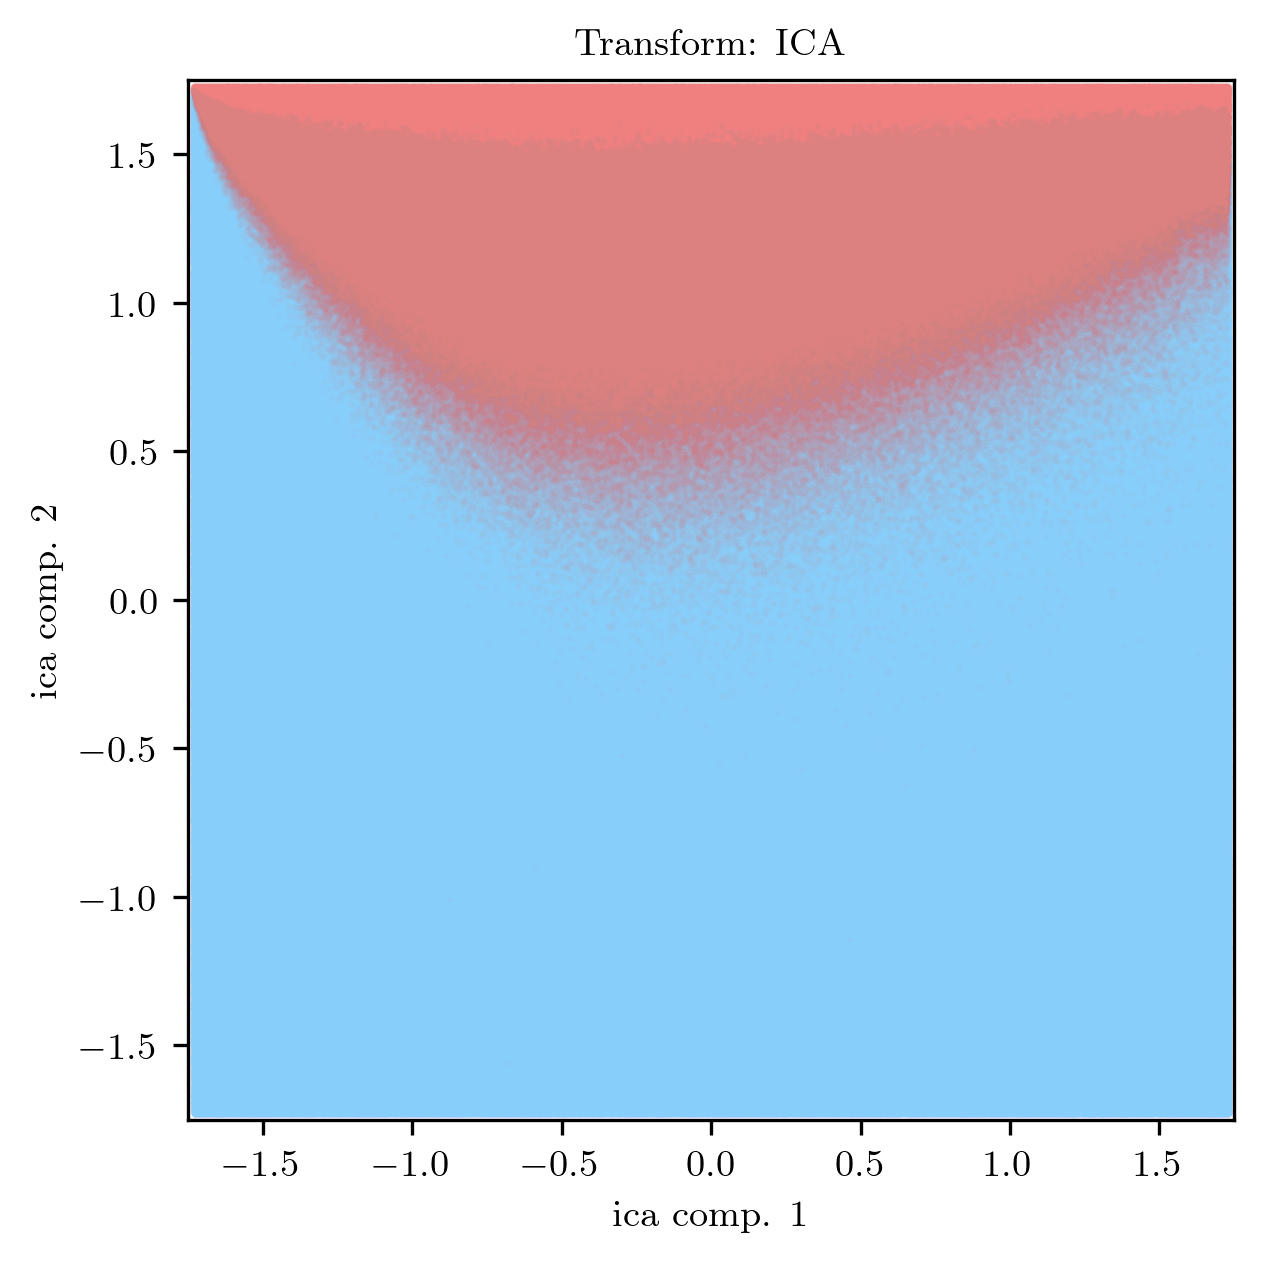

In [43]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(4.5,4.5))

#-------------------------------------------------------------------------
# plot also the data

for i in [0,1]:
    print( x_ica[:,i].min() , x_ica[:,i].max() )

lims_ica = [(-1.75,+1.75),(-1.75,+1.75)]
axlabels_ica = [r'ica comp. 1',r'ica comp. 2']

ax.set_xlim(lims_ica[0])
ax.set_ylim(lims_ica[1])
ax.set_xlabel(axlabels_ica[0])
ax.set_ylabel(axlabels_ica[1])
ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.scatter(x_ica[index_det_n,0] , x_ica[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
ax.scatter(x_ica[index_det_y,0] , x_ica[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax.set_title('Transform: ICA ', fontsize=9)

if False:
    fig.savefig('./L20_images/L20_transform_ICA_Nfeats=2.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_transform_ICA_Nfeats=2.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

In [44]:
#-------------------------------------------------------------------------
# Run the Random Forest classifier
#-------------------------------------------------------------------------

x_train_ICA = ica.transform(x_train)
x_test_ICA  = ica.transform(x_test)
y_train_ICA = y_train
y_test_ICA  = y_test

N_features_ICA = [2]

classifiers_ICA,  \
completeness_ICA, \
contamination_ICA,\
accuracy_ICA,     \
roc_fpr_ICA,      \
roc_tpr_ICA,      \
roc_auc_ICA,      \
= compute_RForest_ICA(
    N_features_ICA, 
    best_depth_2d,
    best_criterion_2d,
    x_train_ICA, 
    y_train_ICA, 
    x_test_ICA, 
    y_test_ICA
)

#-------------------------------------------------------------------------

@pickle_results: computing results and saving to '../../L20_RandomForest_ICA.pkl'
    - args match:   False
    - kwargs match: True


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 1 of 100building tree 5 of 100
building tree 7 of 100
building tree 6 of 100
building tree 3 of 100
building tree 2 of 100
building tree 4 of 100
building tree 8 of 100

building tree 9 of 100
building tree 10 of 100
building tree 11 of 100building tree 12 of 100

building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100


[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  3.8min


building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 16.9min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    4.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   24.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    4.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   25.6s finished


RandomForest depth 12 features 2 done!


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished


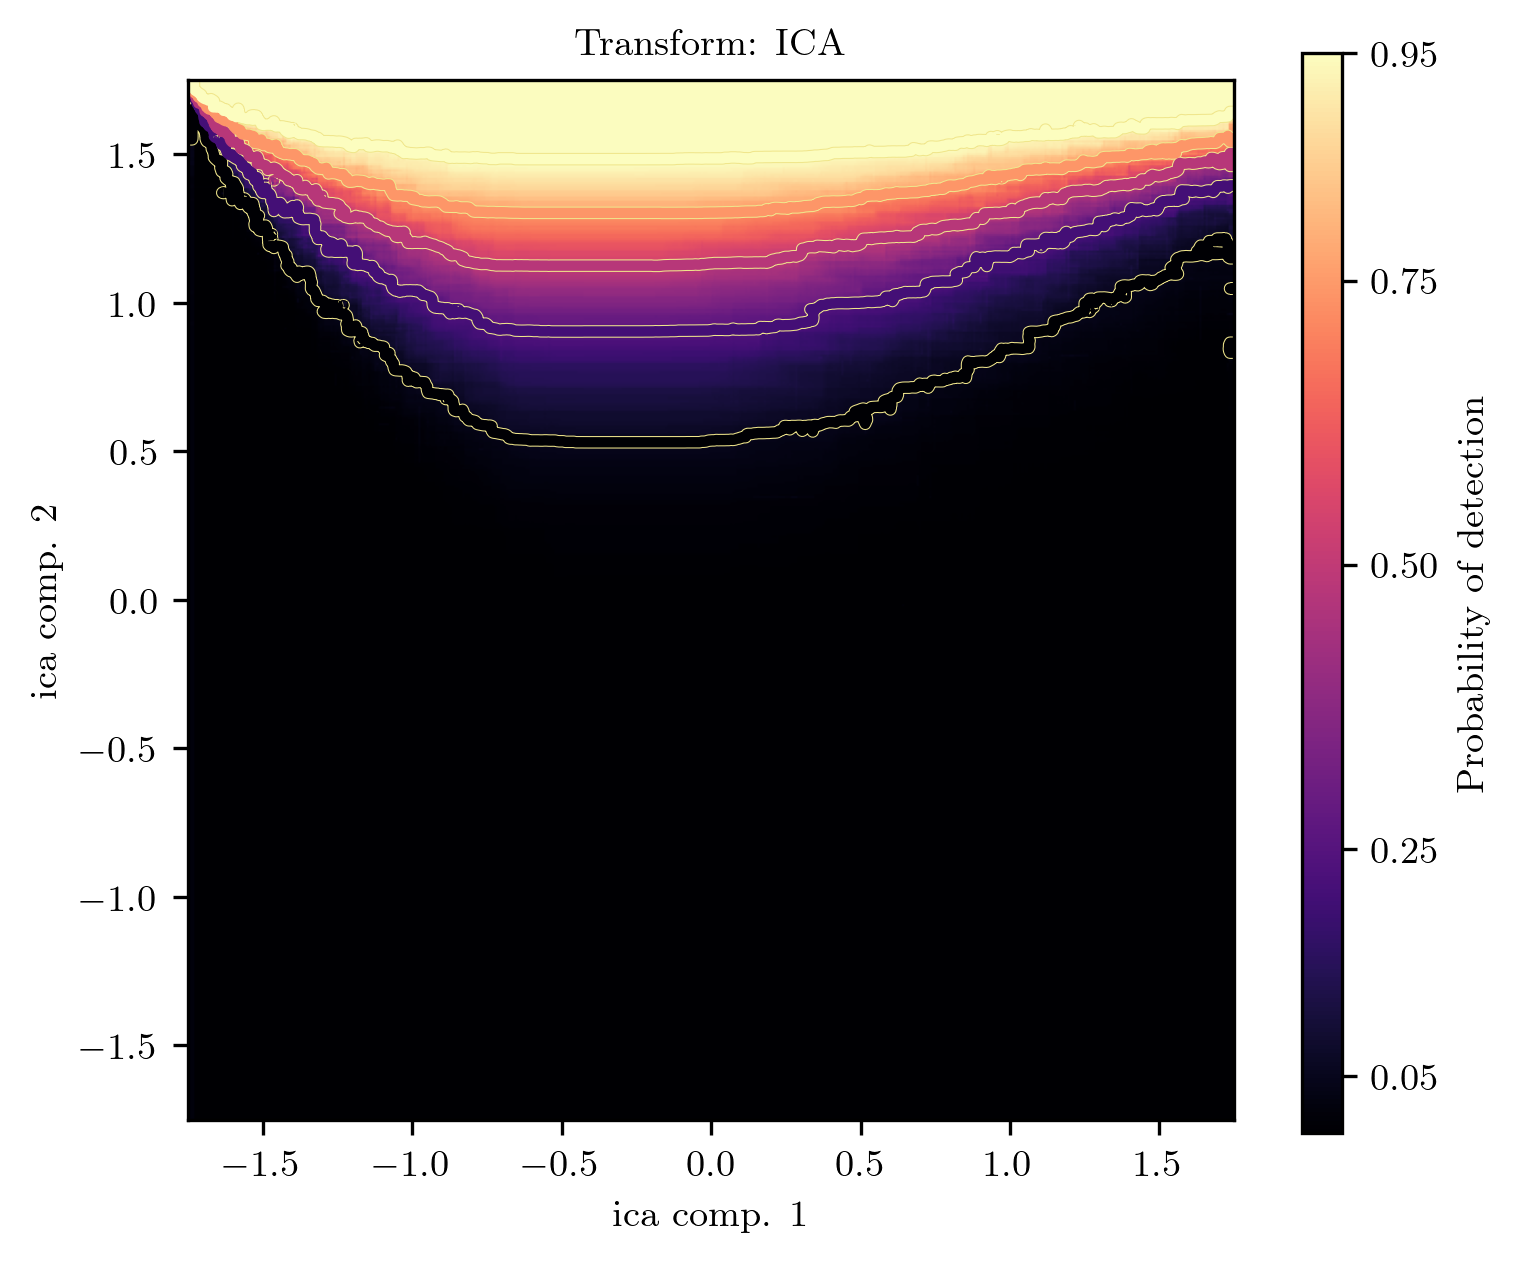

In [45]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(figsize=(4.5,4.5))

#-------------------------------------------------------------------------

x0, x1 = np.meshgrid(
    np.linspace(lims_ica[0][0], lims_ica[0][1], 500),
    np.linspace(lims_ica[1][0], lims_ica[1][1], 500)
)

yy_ica = classifiers_ICA[0].predict_proba(np.c_[x0.ravel(), x1.ravel()])
yy_ica = yy_ica[:,1].reshape(x0.shape)

# x0 = z ; x1 = m_tot
xa = np.linspace(lims_ica[0][0], lims_ica[0][1], 500)
xb = np.linspace(lims_ica[1][0], lims_ica[1][1], 500)
py = yy_ica
ax.contour(xa, xb, py, contours, colors='khaki', linewidths=3.0)
ax.contour(xa, xb, py, contours, cmap=cmap, linewidths=2.5)
im = ax.imshow(py, origin='lower', aspect='auto', cmap=cmap, norm=cmap_norm, zorder=1, extent=lims_ica[0]+lims_ica[1])
cmapax = fig.add_axes([0.95, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(cmapax, cmap=cmap, norm=cmap_norm, ticks=cmap_ticks, format='%.2f')
cmapax.set_ylabel('Probability of detection')

#-------------------------------------------------------------------------
# plot also the data

ax.set_xlim(lims_ica[0])
ax.set_ylim(lims_ica[1])
ax.set_xlabel(axlabels_ica[0])
ax.set_ylabel(axlabels_ica[1])
ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
# ax.scatter(x_ica[index_det_n,0] , x_ica[index_det_n,1] , color='lightskyblue', s=0.1, alpha=0.05)
# ax.scatter(x_ica[index_det_y,0] , x_ica[index_det_y,1] , color='lightcoral', s=0.1, alpha=0.05)

ax.set_title('Transform: ICA ', fontsize=9)

if False:
    fig.savefig('./L20_images/L20_classifier_ICA-RF_Nfeats=2.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_classifier_ICA-RF_Nfeats=2.png', bbox_inches='tight')

del fig
del ax 

#-------------------------------------------------------------------------

# Final comparison of ROC curves and accuracy results

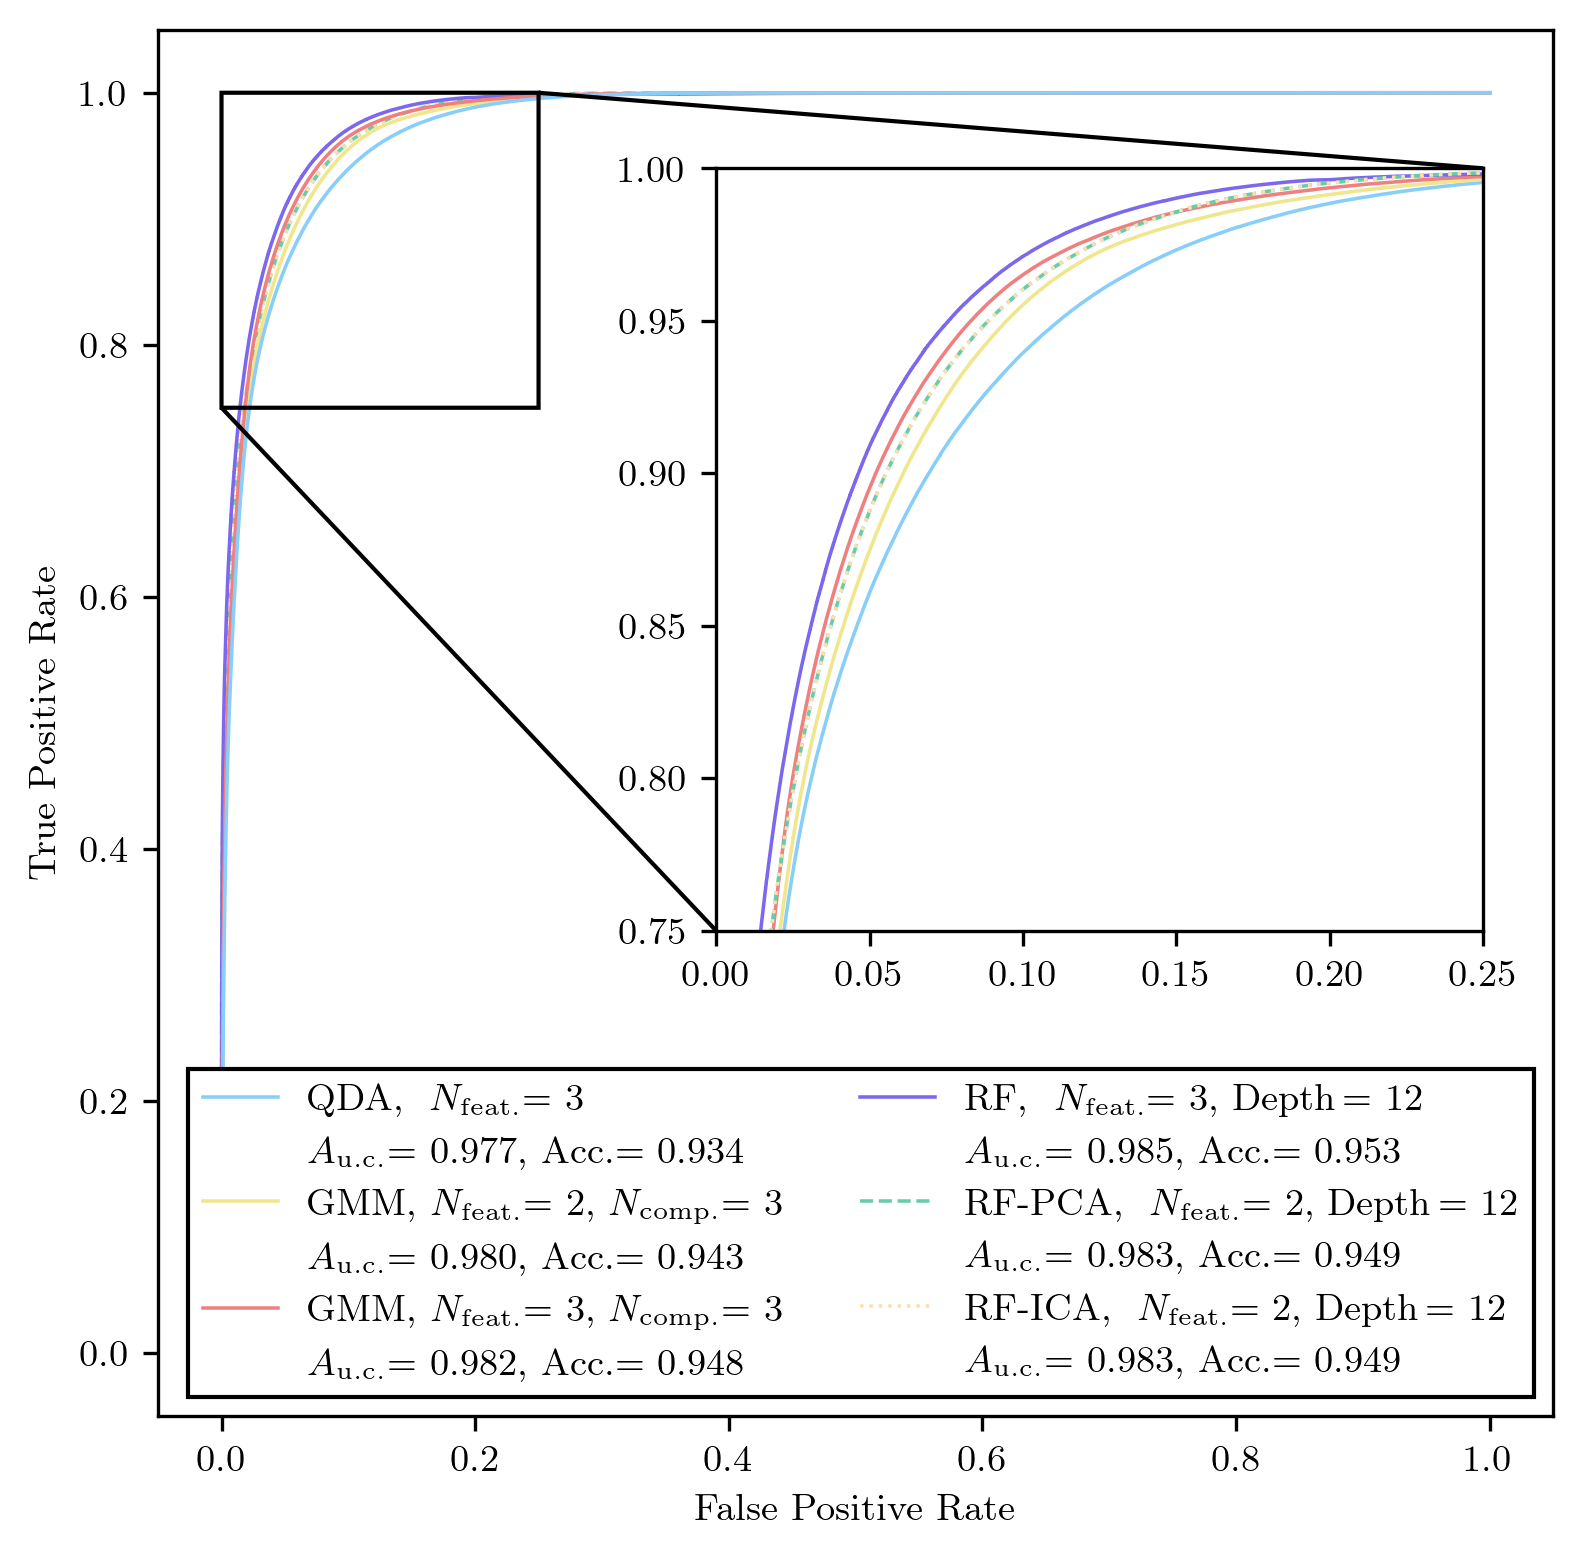

In [48]:
fig, ax = plt.subplots(figsize=(6,6))

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

x_zoom_L, x_zoom_R = 0.0 , 0.25
y_zoom_B, y_zoom_T = 0.75 , 1.0
x_plot_L, x_plot_R = 0.4, 0.95
y_plot_B, y_plot_T = 0.35, 0.9
axins = ax.inset_axes(
    [x_plot_L, y_plot_B, x_plot_R - x_plot_L, y_plot_T - y_plot_B],
    xlim=(x_zoom_L, x_zoom_R), 
    ylim=(y_zoom_B, y_zoom_T)
)

ax.plot(roc_fpr_PCA[-1], roc_tpr_PCA[-1], color='mediumaquamarine', lw=0.85, ls='--')
ax.plot(roc_fpr_ICA[-1], roc_tpr_ICA[-1], color='navajowhite', lw=0.85, ls=':')
# ax.plot(roc_fpr_DTree[-1], roc_tpr_DTree[-1], color='navajowhite', lw=0.85)
ax.plot(roc_fpr_RForest[-1], roc_tpr_RForest[-1], color='mediumslateblue', lw=0.85)
ax.plot(roc_fpr_GMMBayes[3-1][0], roc_tpr_GMMBayes[3-1][0], color='khaki', lw=0.85)
ax.plot(roc_fpr_GMMBayes[3-1][1], roc_tpr_GMMBayes[3-1][1], color='lightcoral', lw=0.85)
ax.plot(roc_fpr_QDA[-1], roc_tpr_QDA[-1], color='lightskyblue', lw=0.85)

label_QDA =  r'$\textup{QDA, }\,\, N_{\rm feat.} $' + '= {:d}'.format(3)
ax.plot([], [], color='lightskyblue', lw=0.85, label=label_QDA)
label_QDA = r'$A_{\rm u. c.} $' + '= {:.3f}'.format(roc_auc_QDA[-1])
label_QDA += ', Acc.= {:.3f}'.format(accuracy_QDA[-1])
ax.plot([], [], ls='', label=label_QDA)
axins.plot(roc_fpr_QDA[-1], roc_tpr_QDA[-1], color='lightskyblue', lw=0.85)

label_GMMBayes_ROC = r'$\textup{GMM, } N_{\rm feat.} $' + '= {:d}'.format(2)
label_GMMBayes_ROC_ij = label_GMMBayes_ROC + r', $N_{\rm comp.} $' + '= {:d}'.format(3)
A_under_curve_ij = roc_auc_GMMBayes[3-1][0]
ax.plot([], [], color='khaki', lw=0.85, label=label_GMMBayes_ROC_ij)
label_GMMBayes_ROC_ij = r'$A_{\rm u. c.} $' + '= {:.3f}'.format(A_under_curve_ij)
label_GMMBayes_ROC_ij += ', Acc.= {:.3f}'.format(accuracy_GMMBayes[3-1][0])
ax.plot([], [], ls='', label=label_GMMBayes_ROC_ij)
axins.plot(roc_fpr_GMMBayes[3-1][0], roc_tpr_GMMBayes[3-1][0], color='khaki', lw=0.85)

label_GMMBayes_ROC = r'$\textup{GMM, } N_{\rm feat.} $' + '= {:d}'.format(3)
label_GMMBayes_ROC_ij = label_GMMBayes_ROC + r', $N_{\rm comp.} $' + '= {:d}'.format(3)
A_under_curve_ij = roc_auc_GMMBayes[3-1][1]
ax.plot([], [], color='lightcoral', lw=0.85, label=label_GMMBayes_ROC_ij)
label_GMMBayes_ROC_ij = r'$A_{\rm u. c.} $' + '= {:.3f}'.format(A_under_curve_ij)
label_GMMBayes_ROC_ij += ', Acc.= {:.3f}'.format(accuracy_GMMBayes[3-1][1])
ax.plot([], [], ls='', label=label_GMMBayes_ROC_ij)
axins.plot(roc_fpr_GMMBayes[3-1][1], roc_tpr_GMMBayes[3-1][1], color='lightcoral', lw=0.85)

label_DTree =  r'$\textup{DT, }\,\, N_{\rm feat.} $' + '= {:d}'.format(3)
label_DTree += r', ${\rm Depth} \,$' + '= {:d}'.format(best_depth_2d)
# ax.plot([], [], color='navajowhite', lw=0.85, label=label_DTree)
label_DTree = r'$A_{\rm u. c.} $' + '= {:.3f}'.format(roc_auc_DTree[-1])
label_DTree += ', Acc.= {:.3f}'.format(accuracy_DTree[-1])
# ax.plot([], [], ls='', label=label_DTree)
# axins.plot(roc_fpr_DTree[-1], roc_tpr_DTree[-1], color='navajowhite', lw=0.85)   # mediumaquamarine

label_RForest =  r'$\textup{RF, }\,\, N_{\rm feat.} $' + '= {:d}'.format(3)
label_RForest += r', ${\rm Depth} \,$' + '= {:d}'.format(best_depth_2d)
ax.plot([], [], color='mediumslateblue', lw=0.85, label=label_RForest)
label_RForest = r'$A_{\rm u. c.} $' + '= {:.3f}'.format(roc_auc_RForest[-1])
label_RForest += ', Acc.= {:.3f}'.format(accuracy_RForest[-1])
ax.plot([], [], ls='', label=label_RForest)
axins.plot(roc_fpr_RForest[-1], roc_tpr_RForest[-1], color='mediumslateblue', lw=0.85)

label_PCA =  r'$\textup{RF-PCA, }\,\, N_{\rm feat.} $' + '= {:d}'.format(2)
label_PCA += r', ${\rm Depth} \,$' + '= {:d}'.format(best_depth_2d)
ax.plot([], [], color='mediumaquamarine', lw=0.85, label=label_PCA, ls='--')
label_PCA = r'$A_{\rm u. c.} $' + '= {:.3f}'.format(roc_auc_PCA[-1])
label_PCA += ', Acc.= {:.3f}'.format(accuracy_PCA[-1])
ax.plot([], [], ls='', label=label_PCA)
axins.plot(roc_fpr_PCA[-1], roc_tpr_PCA[-1], color='mediumaquamarine', lw=0.85, ls='--')

label_ICA =  r'$\textup{RF-ICA, }\,\, N_{\rm feat.} $' + '= {:d}'.format(2)
label_ICA += r', ${\rm Depth} \,$' + '= {:d}'.format(best_depth_2d)
ax.plot([], [], color='navajowhite', lw=0.85, label=label_ICA, ls=':')
label_ICA = r'$A_{\rm u. c.} $' + '= {:.3f}'.format(roc_auc_ICA[-1])
label_ICA += ', Acc.= {:.3f}'.format(accuracy_ICA[-1])
ax.plot([], [], ls='', label=label_ICA)
axins.plot(roc_fpr_ICA[-1], roc_tpr_ICA[-1], color='navajowhite', lw=0.85, ls=':')

ax.indicate_inset_zoom(axins, edgecolor="black", alpha=1)

ax.legend(loc=4, frameon=True, framealpha=1, fancybox=False, edgecolor='black', ncol=2)

if False:
    fig.savefig('./L20_images/L20_roc___comparison.pdf', bbox_inches='tight')
    fig.savefig('./L20_images/L20_roc___comparison.png', bbox_inches='tight')


In [49]:
classifier_overview = pd.DataFrame(
    {
        "classifier": [
            '3-comp GMMB',
            '3-comp GMMB',
            'QDA',
            '12-depth DT', 
            '12-depth RF',
            'PCA + 12-depth RF', 
            'ICA + 12-depth RF'
            ],
        "features": [
            2,3,3,3,3,2,2
            ],
        "completeness": [
            np.round(completeness_GMMBayes[3-1][0], decimals=3),
            np.round(completeness_GMMBayes[3-1][-1], decimals=3),
            np.round(completeness_QDA[-1], decimals=3),
            np.round(completeness_DTree[-1], decimals=3),
            np.round(completeness_RForest[-1], decimals=3),
            np.round(completeness_PCA[-1], decimals=3),
            np.round(completeness_ICA[-1], decimals=3)
            ],
        "contamination": [
            np.round(contamination_GMMBayes[3-1][0], decimals=3),
            np.round(contamination_GMMBayes[3-1][-1], decimals=3),
            np.round(contamination_QDA[-1], decimals=3),
            np.round(contamination_DTree[-1], decimals=3),
            np.round(contamination_RForest[-1], decimals=3),
            np.round(contamination_PCA[-1], decimals=3),
            np.round(contamination_ICA[-1], decimals=3)
            ],
        "accuracy": [
            np.round(accuracy_GMMBayes[3-1][0], decimals=3),
            np.round(accuracy_GMMBayes[3-1][-1], decimals=3),
            np.round(accuracy_QDA[-1], decimals=3),
            np.round(accuracy_DTree[-1], decimals=3),
            np.round(accuracy_RForest[-1], decimals=3),
            np.round(accuracy_PCA[-1], decimals=3),
            np.round(accuracy_ICA[-1], decimals=3)
            ]
    }
)

display(classifier_overview)

# NOTE: remember:

# Precision = Efficiency 
#           = 1 - Contamination 
#           = 1 - false discovery rate 
#           = 100% - (GAL incorrectly identified as QSR) / (all identifications as QSR, right and wrong)

# Completeness = Recall 
#              = True positive rate 
#              = (correctly identified QSR) / (all QSR in data, identified and hidden) 

,classifier,features,completeness,contamination,accuracy
0,3-comp GMMB,2,0.847,0.221,0.943
1,3-comp GMMB,3,0.852,0.200,0.948
2,QDA,3,0.876,0.278,0.934
3,12-depth DT,3,0.811,0.145,0.953
4,12-depth RF,3,0.806,0.140,0.953
5,PCA + 12-depth RF,2,0.785,0.149,0.949
6,ICA + 12-depth RF,2,0.786,0.149,0.949


In [ ]:
x_isomap = isomap.fit_transform(x_debug)

In [ ]:
x_tsne   = tsne.fit_transform(x_debug)